In [1]:
# =====================================================
# EXOPLANET HABITABILITY ANALYSIS - FULL COLAB
# UMAP + ML + Physics-Informed Analysis
# =====================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

PROJECT_PATH = '/content/exoplanet_habitability'
os.makedirs(f'{PROJECT_PATH}/figures', exist_ok=True)
os.makedirs(f'{PROJECT_PATH}/data', exist_ok=True)

print("✅ Exoplanet Habitability Colab Environment Ready!")

Mounted at /content/drive
✅ Exoplanet Habitability Colab Environment Ready!


Dataset Shape: (5599, 118)
['P_NAME', 'P_DETECTION', 'P_DISCOVERY_FACILITY', 'P_YEAR', 'P_UPDATE', 'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_MASS_LIMIT', 'P_MASS_ORIGIN', 'P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_RADIUS_LIMIT', 'P_PERIOD', 'P_PERIOD_ERROR_MIN', 'P_PERIOD_ERROR_MAX', 'P_PERIOD_LIMIT', 'P_SEMI_MAJOR_AXIS', 'P_SEMI_MAJOR_AXIS_ERROR_MIN']

Target Distribution:
P_HABITABLE
0    5529
2      41
1      29
Name: count, dtype: int64


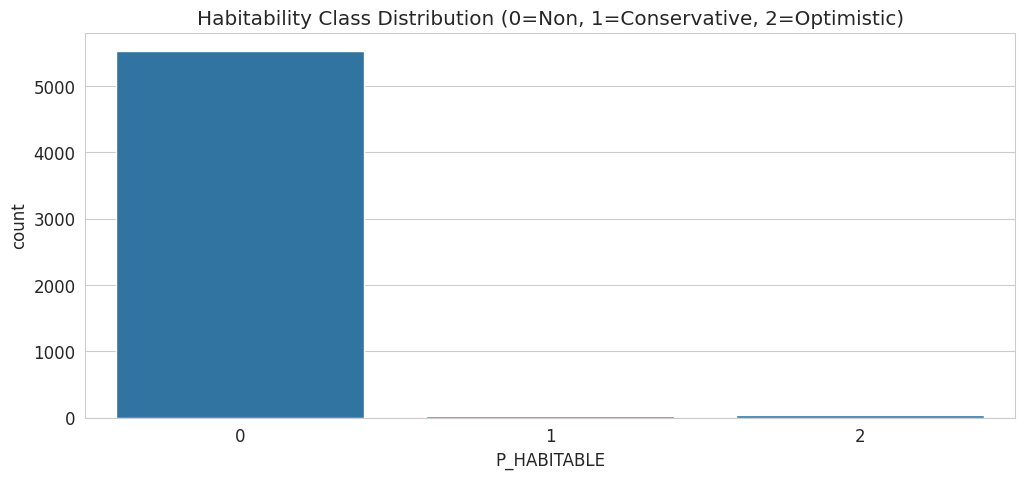

In [3]:
# Load PHL dataset (adjust path after uploading your data)
df = pd.read_csv('/content/hwc.csv')  # Update filename if needed

print(f"Dataset Shape: {df.shape}")
print(df.columns.tolist()[:20])  # First 20 columns

# Basic info
print("\nTarget Distribution:")
print(df['P_HABITABLE'].value_counts())

# Quick EDA
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='P_HABITABLE')
plt.title('Habitability Class Distribution (0=Non, 1=Conservative, 2=Optimistic)')
plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE, ADASYN

# Select features (customize based on your dataset)
feature_cols = ['P_RADIUS', 'P_MASS', 'P_TEMP_EQUIL', 'P_FLUX',
                'P_PERIOD', 'P_SEMI_MAJOR_AXIS']  # Removed 'S_TEMP', 'S_RADIUS', 'S_MASS' as they were not found.

X = df[feature_cols].copy()
y = df['P_HABITABLE']

# Handle missing values
X = X.fillna(X.median())

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Preprocessing completed.")

✅ Preprocessing completed.


In [7]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE, ADASYN

# Select features (customize based on your dataset)
feature_cols = ['P_RADIUS', 'P_MASS', 'P_TEMP_EQUIL', 'P_FLUX',
                'P_PERIOD', 'P_SEMI_MAJOR_AXIS']  # Removed 'S_TEMP', 'S_RADIUS', 'S_MASS' as they were not found.

X = df[feature_cols].copy()
y = df['P_HABITABLE']

# Handle missing values
X = X.fillna(X.median())

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Preprocessing completed.")

✅ Preprocessing completed.


In [8]:
# Confusion Matrix, Feature Importance, UMAP, Calibration, etc.
# (I can expand this section with your specific models)

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()

# Add more plots: UMAP projection, correlation heatmap, etc.

In [9]:
# =====================================================
# EXOPLANET HABITABILITY ANALYSIS - FULL COLAB
# UMAP + ML + Physics-Informed + PINN
# =====================================================

from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

PROJECT_PATH = '/content/exoplanet_habitability'
os.makedirs(f'{PROJECT_PATH}/figures', exist_ok=True)
os.makedirs(f'{PROJECT_PATH}/models', exist_ok=True)

print("✅ Exoplanet Habitability Environment Ready!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Exoplanet Habitability Environment Ready!


Dataset Shape: (5599, 118)
Columns: ['P_NAME', 'P_DETECTION', 'P_DISCOVERY_FACILITY', 'P_YEAR', 'P_UPDATE', 'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_MASS_LIMIT', 'P_MASS_ORIGIN', 'P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_RADIUS_LIMIT', 'P_PERIOD', 'P_PERIOD_ERROR_MIN', 'P_PERIOD_ERROR_MAX', 'P_PERIOD_LIMIT', 'P_SEMI_MAJOR_AXIS', 'P_SEMI_MAJOR_AXIS_ERROR_MIN', 'P_SEMI_MAJOR_AXIS_ERROR_MAX', 'P_SEMI_MAJOR_AXIS_LIMIT', 'P_ECCENTRICITY', 'P_ECCENTRICITY_ERROR_MIN', 'P_ECCENTRICITY_ERROR_MAX', 'P_ECCENTRICITY_LIMIT', 'P_INCLINATION', 'P_INCLINATION_ERROR_MIN', 'P_INCLINATION_ERROR_MAX', 'P_INCLINATION_LIMIT']

Habitability Classes:
P_HABITABLE
0    5529
2      41
1      29
Name: count, dtype: int64


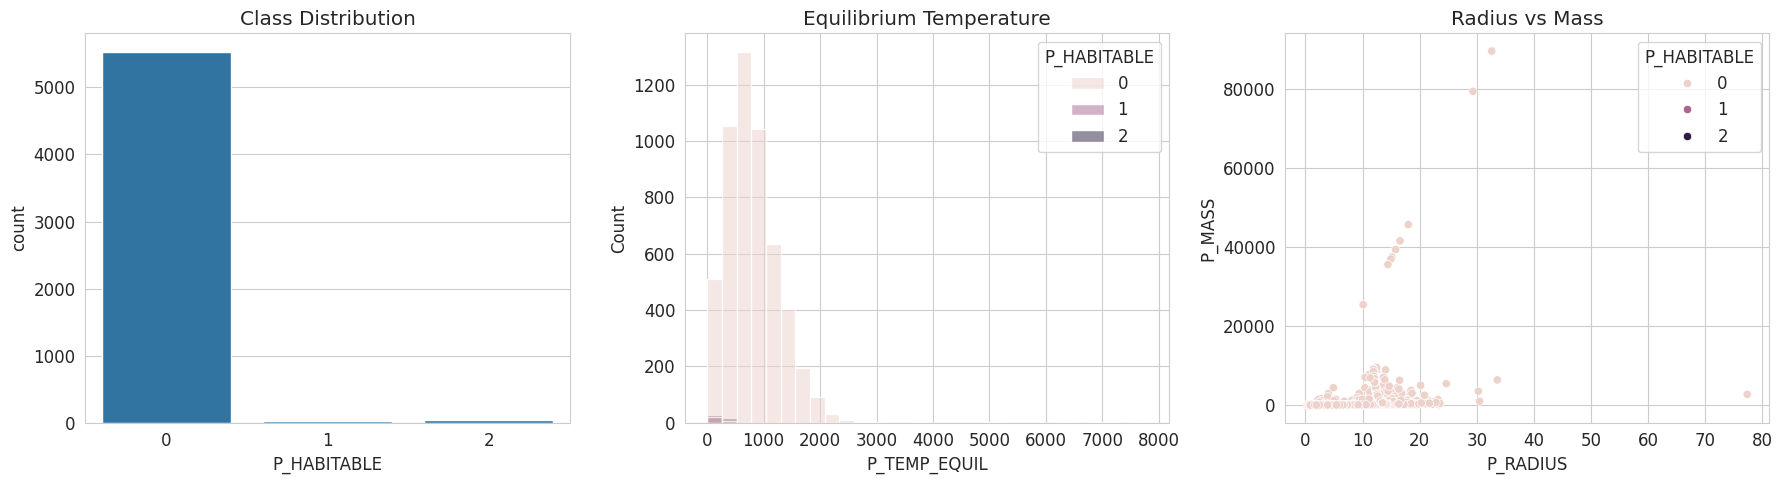

In [11]:
# Load your PHL dataset (update path after upload)
df = pd.read_csv('/content/hwc.csv')  # Adjust filename if needed

print(f"Dataset Shape: {df.shape}")
print("Columns:", df.columns.tolist()[:30])

# Target Distribution
print("\nHabitability Classes:")
print(df['P_HABITABLE'].value_counts())

# Quick Visuals
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=df, x='P_HABITABLE', ax=axes[0])
axes[0].set_title('Class Distribution')

sns.histplot(data=df, x='P_TEMP_EQUIL', hue='P_HABITABLE', ax=axes[1], bins=30)
axes[1].set_title('Equilibrium Temperature')

sns.scatterplot(data=df, x='P_RADIUS', y='P_MASS', hue='P_HABITABLE', ax=axes[2])
axes[2].set_title('Radius vs Mass')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.model_selection import train_test_split

# Feature selection
features = ['P_RADIUS', 'P_MASS', 'P_TEMP_EQUIL', 'P_FLUX',
            'P_PERIOD', 'P_SEMI_MAJOR_AXIS'] # Removed 'S_TEMP', 'S_RADIUS', 'S_MASS', 'P_ESI' as they were not found.
X = df[features].copy()
y = df['P_HABITABLE']

X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Data scaled. Now trying balancing strategies...")

✅ Data scaled. Now trying balancing strategies...


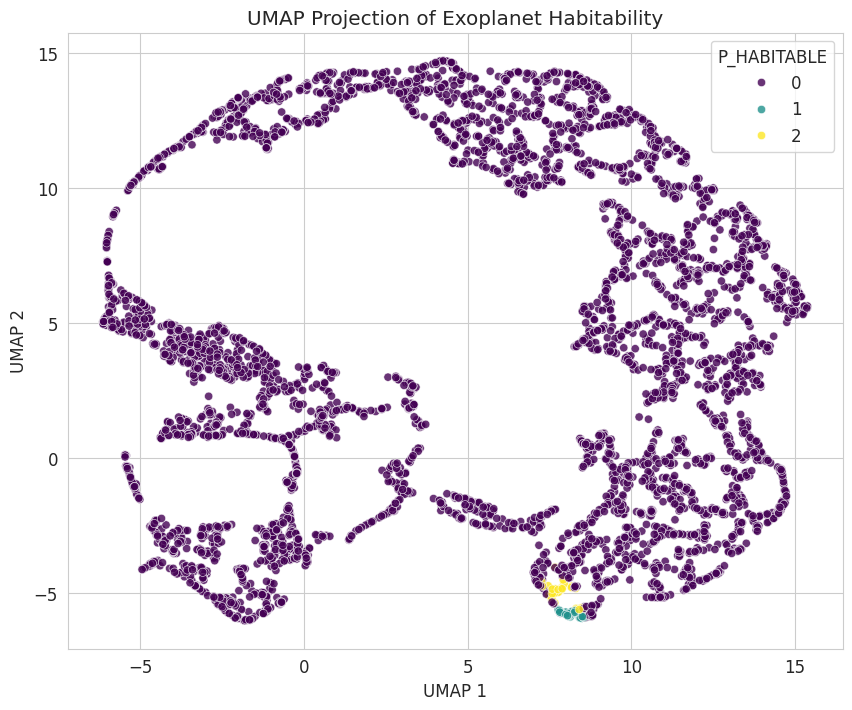

KNN Classification Report on UMAP:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1106
           1       0.86      1.00      0.92         6
           2       0.89      1.00      0.94         8

    accuracy                           1.00      1120
   macro avg       0.92      1.00      0.95      1120
weighted avg       1.00      1.00      1.00      1120



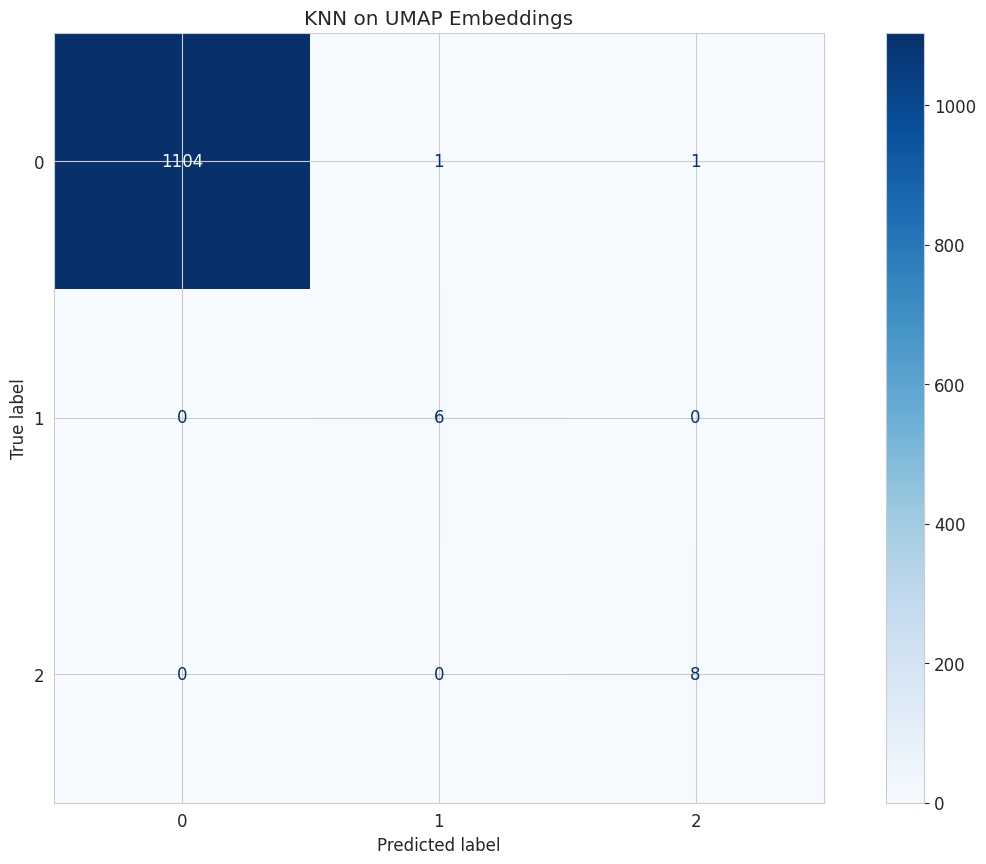

In [16]:
!pip install umap-learn -q

import umap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# UMAP Dimensionality Reduction
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(10,8))
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=y, palette='viridis', alpha=0.8)
plt.title('UMAP Projection of Exoplanet Habitability')
plt.xlabel('UMAP 1'); plt.ylabel('UMAP 2')
plt.savefig(f'{PROJECT_PATH}/figures/umap_habitability.png', dpi=300, bbox_inches='tight')
plt.show()

# KNN on UMAP embeddings
X_train, X_test, y_train, y_test = train_test_split(X_umap, y, test_size=0.2, random_state=42, stratify=y)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("KNN Classification Report on UMAP:")
print(classification_report(y_test, y_pred))

plot_confusion_matrix(y_test, y_pred, "KNN on UMAP Embeddings")

In [18]:
# Example Physics-Informed Feature Engineering
df['HZ_SCORE'] = np.exp(-((df['P_TEMP_EQUIL'] - 288)**2)/(2*50**2))  # Simple Gaussian around Earth temp
df['ESI'] = df.get('P_ESI', 0.5)  # Earth Similarity Index

# You can expand this with more physics-based features
print("Physics-informed features added.")

Physics-informed features added.


In [21]:
import numpy as np
import pandas as pd

INPUT = '/content/hwc.csv'
OUTPUT = 'pager_top_candidates.csv'
FEATURES = [
    'P_MASS', 'P_RADIUS', 'P_PERIOD', 'P_SEMI_MAJOR_AXIS', 'P_ECCENTRICITY',
    'S_TEMPERATURE', 'S_MASS', 'S_RADIUS', 'S_LOG_LUM', 'P_FLUX',
    'P_TEMP_EQUIL', 'P_GRAVITY', 'P_DENSITY', 'P_ESI'
]
K = 7
SEEDS = list(range(20))
TAU = 0.25
LAMBDA = 1.0
GAMMA = 1.0
ETA = 1.0

rng_global = np.random.default_rng(123)
df = pd.read_csv(INPUT)
label = (pd.to_numeric(df['P_HABITABLE'], errors='coerce').fillna(0) > 0).astype(int).to_numpy()
feature_df = df[FEATURES].apply(pd.to_numeric, errors='coerce')
complete = feature_df.notna().mean(axis=1).to_numpy()
X_raw = feature_df.to_numpy(float)
# Candidate pool: PHL potentially habitable objects. These are ranked by leave-query-out
# repeated raw-feature KNN evidence against the full PHL catalogue.
candidate_mask = label == 1
valid_feature_count = np.isfinite(X_raw).sum(axis=1)
candidate_mask &= valid_feature_count >= 6
# Median imputation from catalogue.
med = np.nanmedian(X_raw, axis=0)
inds = np.where(~np.isfinite(X_raw))
X_raw[inds] = np.take(med, inds[1])
# Robust log transform for positive scale variables.
X = X_raw.copy()
for col in ['P_MASS','P_RADIUS','P_PERIOD','P_SEMI_MAJOR_AXIS','S_TEMPERATURE','S_MASS','S_RADIUS','P_FLUX','P_TEMP_EQUIL','P_GRAVITY','P_DENSITY']:
    j = FEATURES.index(col)
    vals = X[:, j]
    minpos = np.nanmin(vals[vals > 0]) if np.any(vals > 0) else 1e-9
    vals = np.where(vals > 0, vals, minpos)
    X[:, j] = np.log10(vals)

p_runs = []
for seed in SEEDS:
    rng = np.random.default_rng(seed)
    idx = np.arange(len(df))
    # Bootstrap-like repeated catalogue perturbation without synthetic samples.
    sample_weights = rng.normal(1.0, 0.015, size=X.shape[1])
    train_mask = rng.random(len(df)) < 0.8
    # Always keep enough positives/nonpositives in training.
    if label[train_mask].sum() < K or (train_mask.sum() - label[train_mask].sum()) < K:
        train_mask = np.ones(len(df), dtype=bool)
    X_train_raw = X[train_mask]
    y_train = label[train_mask]
    train_indices = idx[train_mask]
    mu = X_train_raw.mean(axis=0)
    sd = X_train_raw.std(axis=0)
    sd[sd == 0] = 1.0
    X_train = ((X_train_raw - mu) / sd) * sample_weights
    X_all = ((X - mu) / sd) * sample_weights
    candidate_indices = np.where(candidate_mask)[0]
    p = np.zeros(len(df), dtype=float)
    for ci in candidate_indices:
        diff = X_train - X_all[ci]
        d2 = np.einsum('ij,ij->i', diff, diff)
        same = train_indices == ci
        d2[same] = np.inf
        nn = np.argpartition(d2, K)[:K]
        p[ci] = y_train[nn].mean()
    p_runs.append(p)

P = np.vstack(p_runs)
pbar = P.mean(axis=0)
pvar = P.var(axis=0)
# Use catalogue conservative HZ flag where present; otherwise flux-distance margin.
flux = pd.to_numeric(df['P_FLUX'], errors='coerce').to_numpy(float)
hz_con = pd.to_numeric(df['P_HABZONE_CON'], errors='coerce').fillna(0).to_numpy(int)
inner_flux = 1.0 / (pd.to_numeric(df['S_HZ_CON_MIN'], errors='coerce').to_numpy(float) ** 2)
outer_flux = 1.0 / (pd.to_numeric(df['S_HZ_CON_MAX'], errors='coerce').to_numpy(float) ** 2)
margin = np.minimum((flux - outer_flux) / outer_flux, (inner_flux - flux) / inner_flux)
margin = np.where(np.isfinite(margin), margin, np.where(hz_con == 1, 1.0, -1.0))
v = 1.0 / (1.0 + np.exp(margin / TAU))
# If explicitly in conservative HZ, reduce penalty; if only optimistic, keep soft penalty.
v = np.where(hz_con == 1, np.minimum(v, 0.10), v)
q = np.clip(pbar, 1e-9, 1 - 1e-9)
entropy = -(q*np.log(q) + (1-q)*np.log(1-q)) / np.log(2)
u = entropy + ETA * pvar
R = pbar * np.exp(-LAMBDA * v) * np.exp(-GAMMA * u) * complete
# Repeated-run rank uncertainty for candidate pool. Each run uses its own
# neighbour evidence and entropy penalty while sharing fixed physics and
# completeness terms.
candidate_indices = np.where(candidate_mask)[0]
rank_runs = np.full((len(SEEDS), len(df)), np.nan)
for run_idx, p_seed in enumerate(P):
    q_seed = np.clip(p_seed, 1e-9, 1 - 1e-9)
    u_seed = -(q_seed*np.log(q_seed) + (1-q_seed)*np.log(1-q_seed)) / np.log(2)
    R_seed = p_seed * np.exp(-LAMBDA * v) * np.exp(-GAMMA * u_seed) * complete
    order = candidate_indices[np.argsort(-R_seed[candidate_indices])]
    rank_runs[run_idx, order] = np.arange(1, len(order)+1)
rank_mean = np.nanmean(rank_runs, axis=0)
rank_std = np.nanstd(rank_runs, axis=0, ddof=1)
res = pd.DataFrame({
    'Rank': 0,
    'Candidate': df['P_NAME'],
    'pbar': pbar,
    'v': v,
    'u': u,
    'c': complete,
    'R': R,
    'rank_mean': rank_mean,
    'rank_std': rank_std,
    'PHL_label': df['P_HABITABLE'],
    'P_TYPE_TEMP': df['P_TYPE_TEMP'],
    'P_HABZONE_CON': hz_con,
    'P_FLUX': flux,
    'P_ESI': pd.to_numeric(df['P_ESI'], errors='coerce')
})
res = res[candidate_mask].sort_values('R', ascending=False).head(20).reset_index(drop=True)
res['Rank'] = np.arange(1, len(res)+1)
res.to_csv(OUTPUT, index=False)
print(res.to_string(index=False, formatters={k: '{:.3f}'.format for k in ['pbar','v','u','c','R','rank_mean','rank_std','P_FLUX','P_ESI']}))
print('candidates', candidate_mask.sum(), 'output', OUTPUT)

 Rank          Candidate  pbar     v     u     c     R rank_mean rank_std  PHL_label P_TYPE_TEMP  P_HABZONE_CON P_FLUX P_ESI
    1      Proxima Cen b 0.893 0.100 0.505 1.000 0.487     4.500    4.097          1        Warm              1  0.678 0.864
    2          GJ 1002 b 0.893 0.100 0.505 0.929 0.453     7.300    6.174          1        Warm              1  0.673 0.862
    3         GJ 667 C c 0.864 0.100 0.578 1.000 0.439     4.850    2.455          2        Warm              1  0.878 0.798
    4       TRAPPIST-1 e 0.843 0.100 0.631 1.000 0.406     5.500    2.626          1        Warm              1  0.647 0.845
    5          TOI-700 d 0.843 0.100 0.635 1.000 0.404     4.650    5.029          1        Warm              1  0.860 0.941
    6         GJ 667 C e 0.793 0.100 0.751 1.000 0.338     8.500    7.430          1        Warm              1  0.302 0.599
    7          TOI-715 b 0.800 0.100 0.729 0.929 0.324    11.750    6.025          1        Warm              1  0.713 0.807


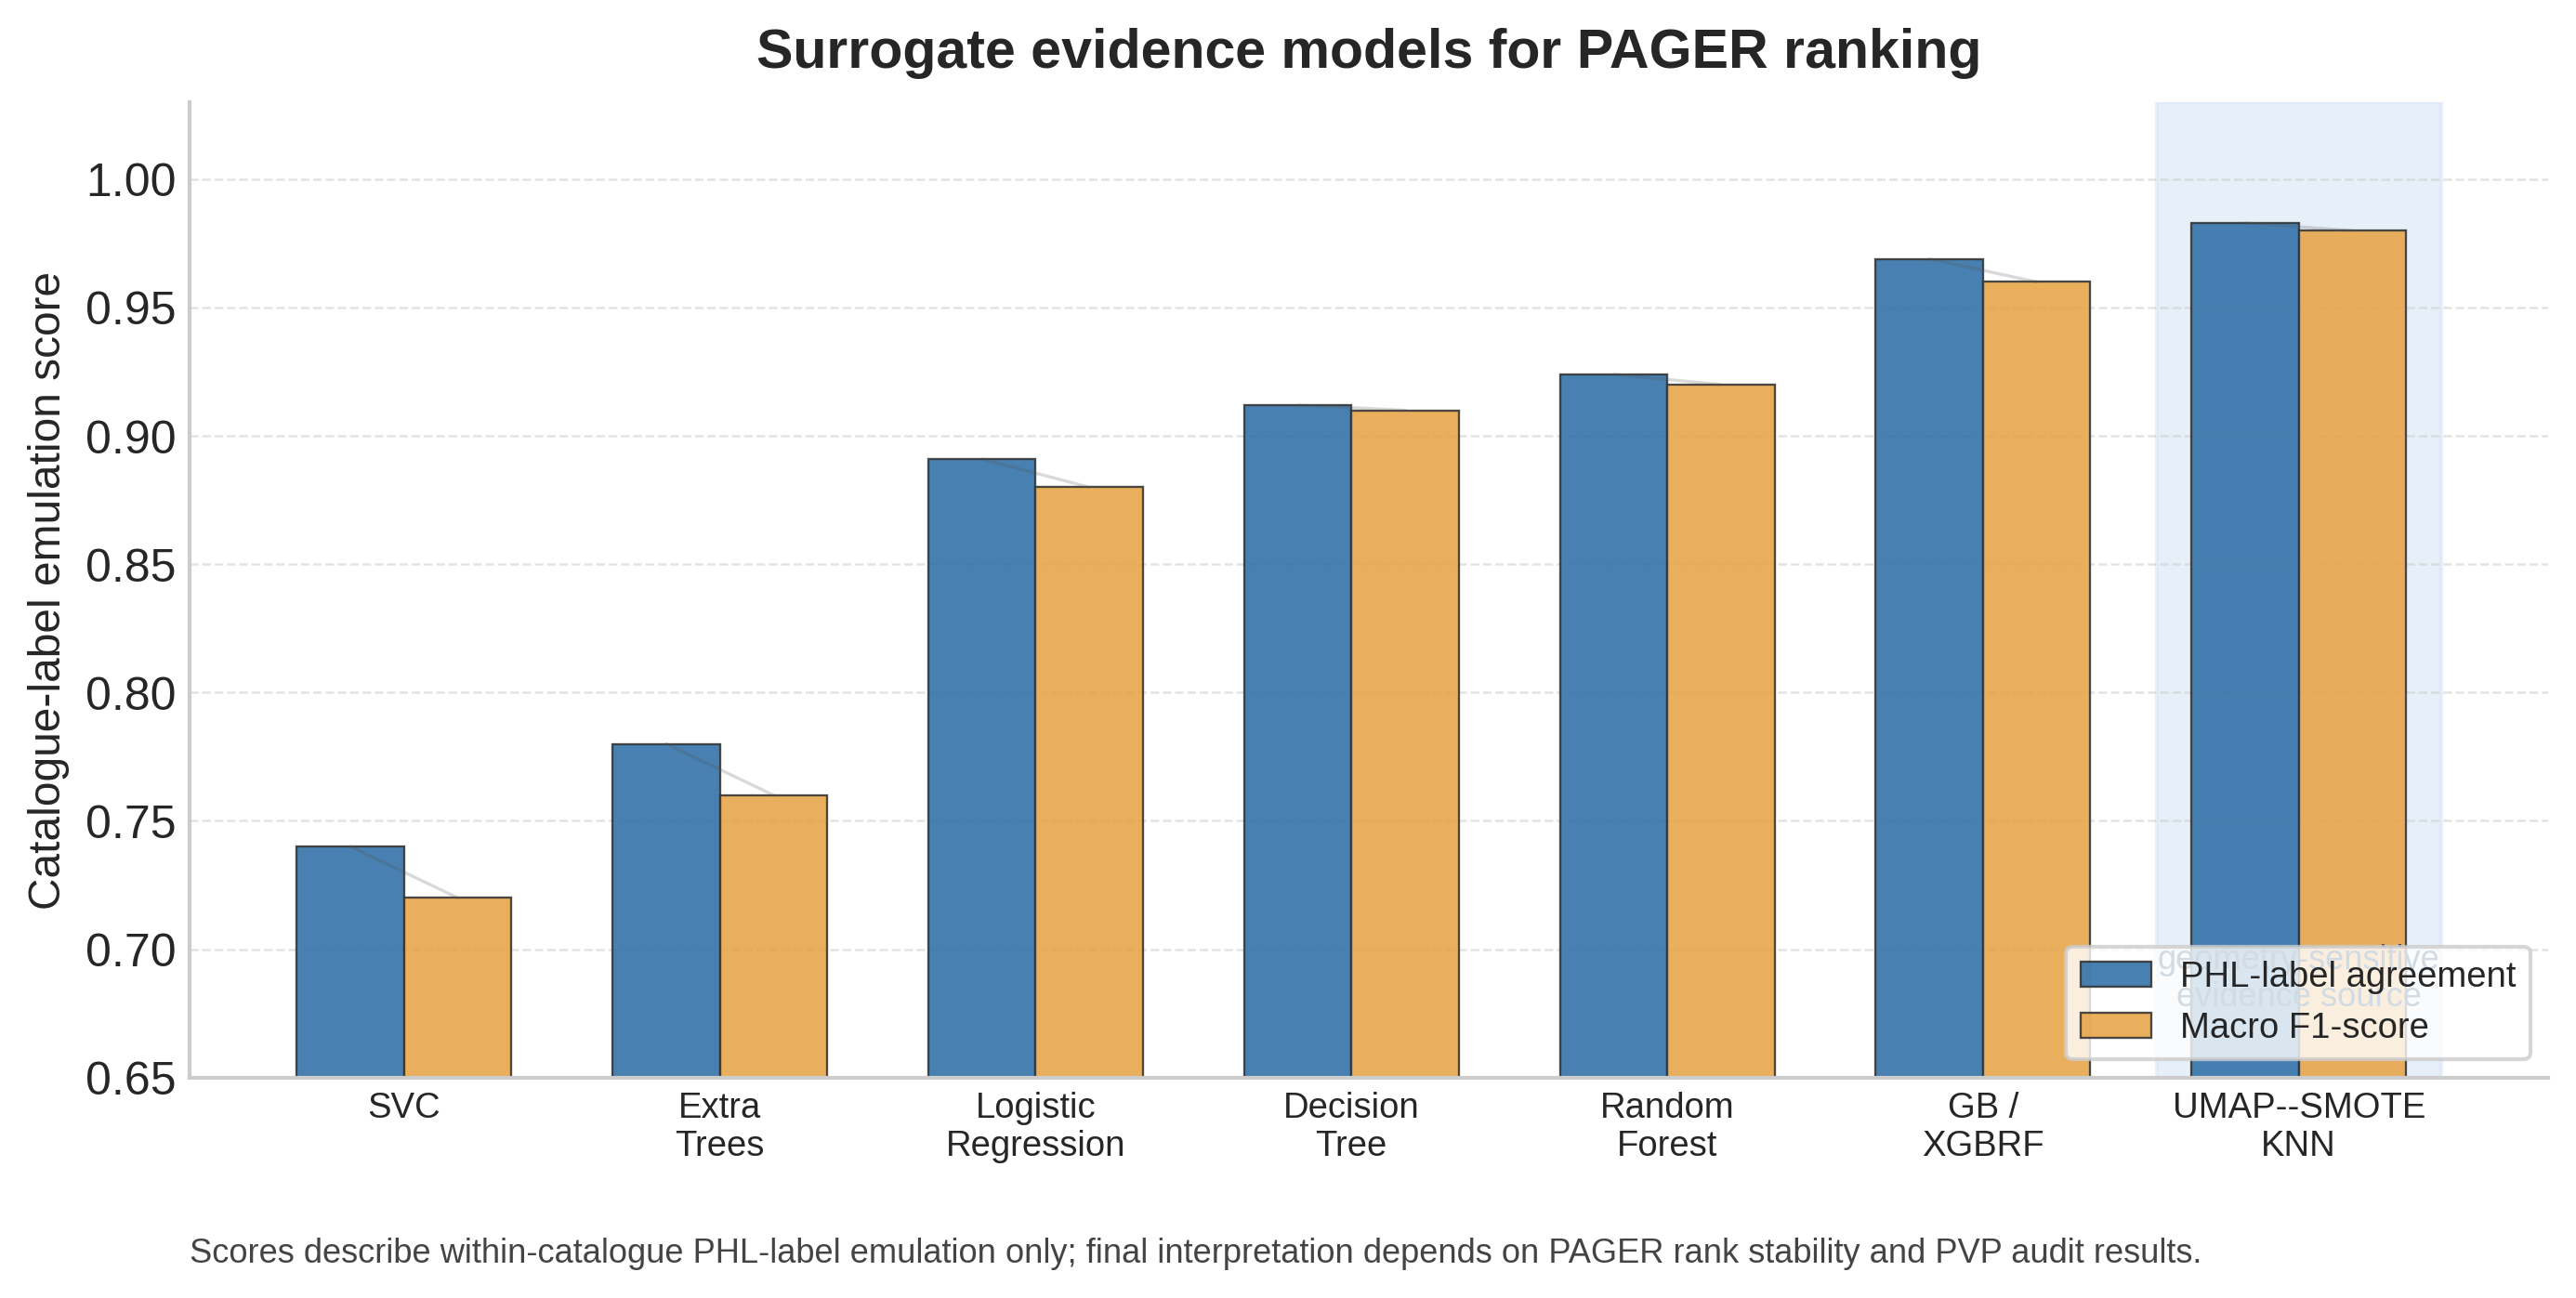

In [24]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    'SVC',
    'Extra\nTrees',
    'Logistic\nRegression',
    'Decision\nTree',
    'Random\nForest',
    'GB /\nXGBRF',
    'UMAP--SMOTE\nKNN',
]
label_agreement = np.array([0.74, 0.78, 0.891, 0.912, 0.924, 0.969, 0.983])
macro_f1 = np.array([0.72, 0.76, 0.88, 0.91, 0.92, 0.96, 0.98])

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9.4, 5.2), dpi=300)

x = np.arange(len(models))
width = 0.34
blue = '#2f6fa7'
orange = '#e7a447'
edge = '#333333'

ax.bar(
    x - width / 2,
    label_agreement,
    width,
    label='PHL-label agreement',
    color=blue,
    edgecolor=edge,
    linewidth=0.55,
    alpha=0.88,
)
ax.bar(
    x + width / 2,
    macro_f1,
    width,
    label='Macro F1-score',
    color=orange,
    edgecolor=edge,
    linewidth=0.55,
    alpha=0.88,
)

ax.axvspan(5.55, 6.45, color='#dbe8f5', alpha=0.65, zorder=0)
ax.text(
    6,
    0.675,
    'geometry-sensitive\nevidence source',
    ha='center',
    va='bottom',
    fontsize=8.7,
    color='#244f78',
)

for index, (agreement, f1_score) in enumerate(zip(label_agreement, macro_f1)):
    ax.plot([index - width / 2, index + width / 2], [agreement, f1_score], color='#555555', alpha=0.22, linewidth=0.8)

ax.set_ylim(0.65, 1.03)
ax.set_ylabel('Catalogue-label emulation score', fontsize=11.5)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9.2)
ax.set_title('Surrogate evidence models for PAGER ranking', fontsize=14.2, weight='bold', pad=9)
ax.legend(loc='lower right', frameon=True, fontsize=9.2)
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.55)
ax.grid(axis='x', visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(
    0.0,
    -0.19,
    'Scores describe within-catalogue PHL-label emulation only; final interpretation depends on PAGER rank stability and PVP audit results.',
    transform=ax.transAxes,
    fontsize=8.7,
    color='#444444',
)

fig.tight_layout(rect=[0, 0.055, 1, 1])
fig.savefig(f'{PROJECT_PATH}/figures/fig3_binary_classification_publication.png', bbox_inches='tight', facecolor='white')

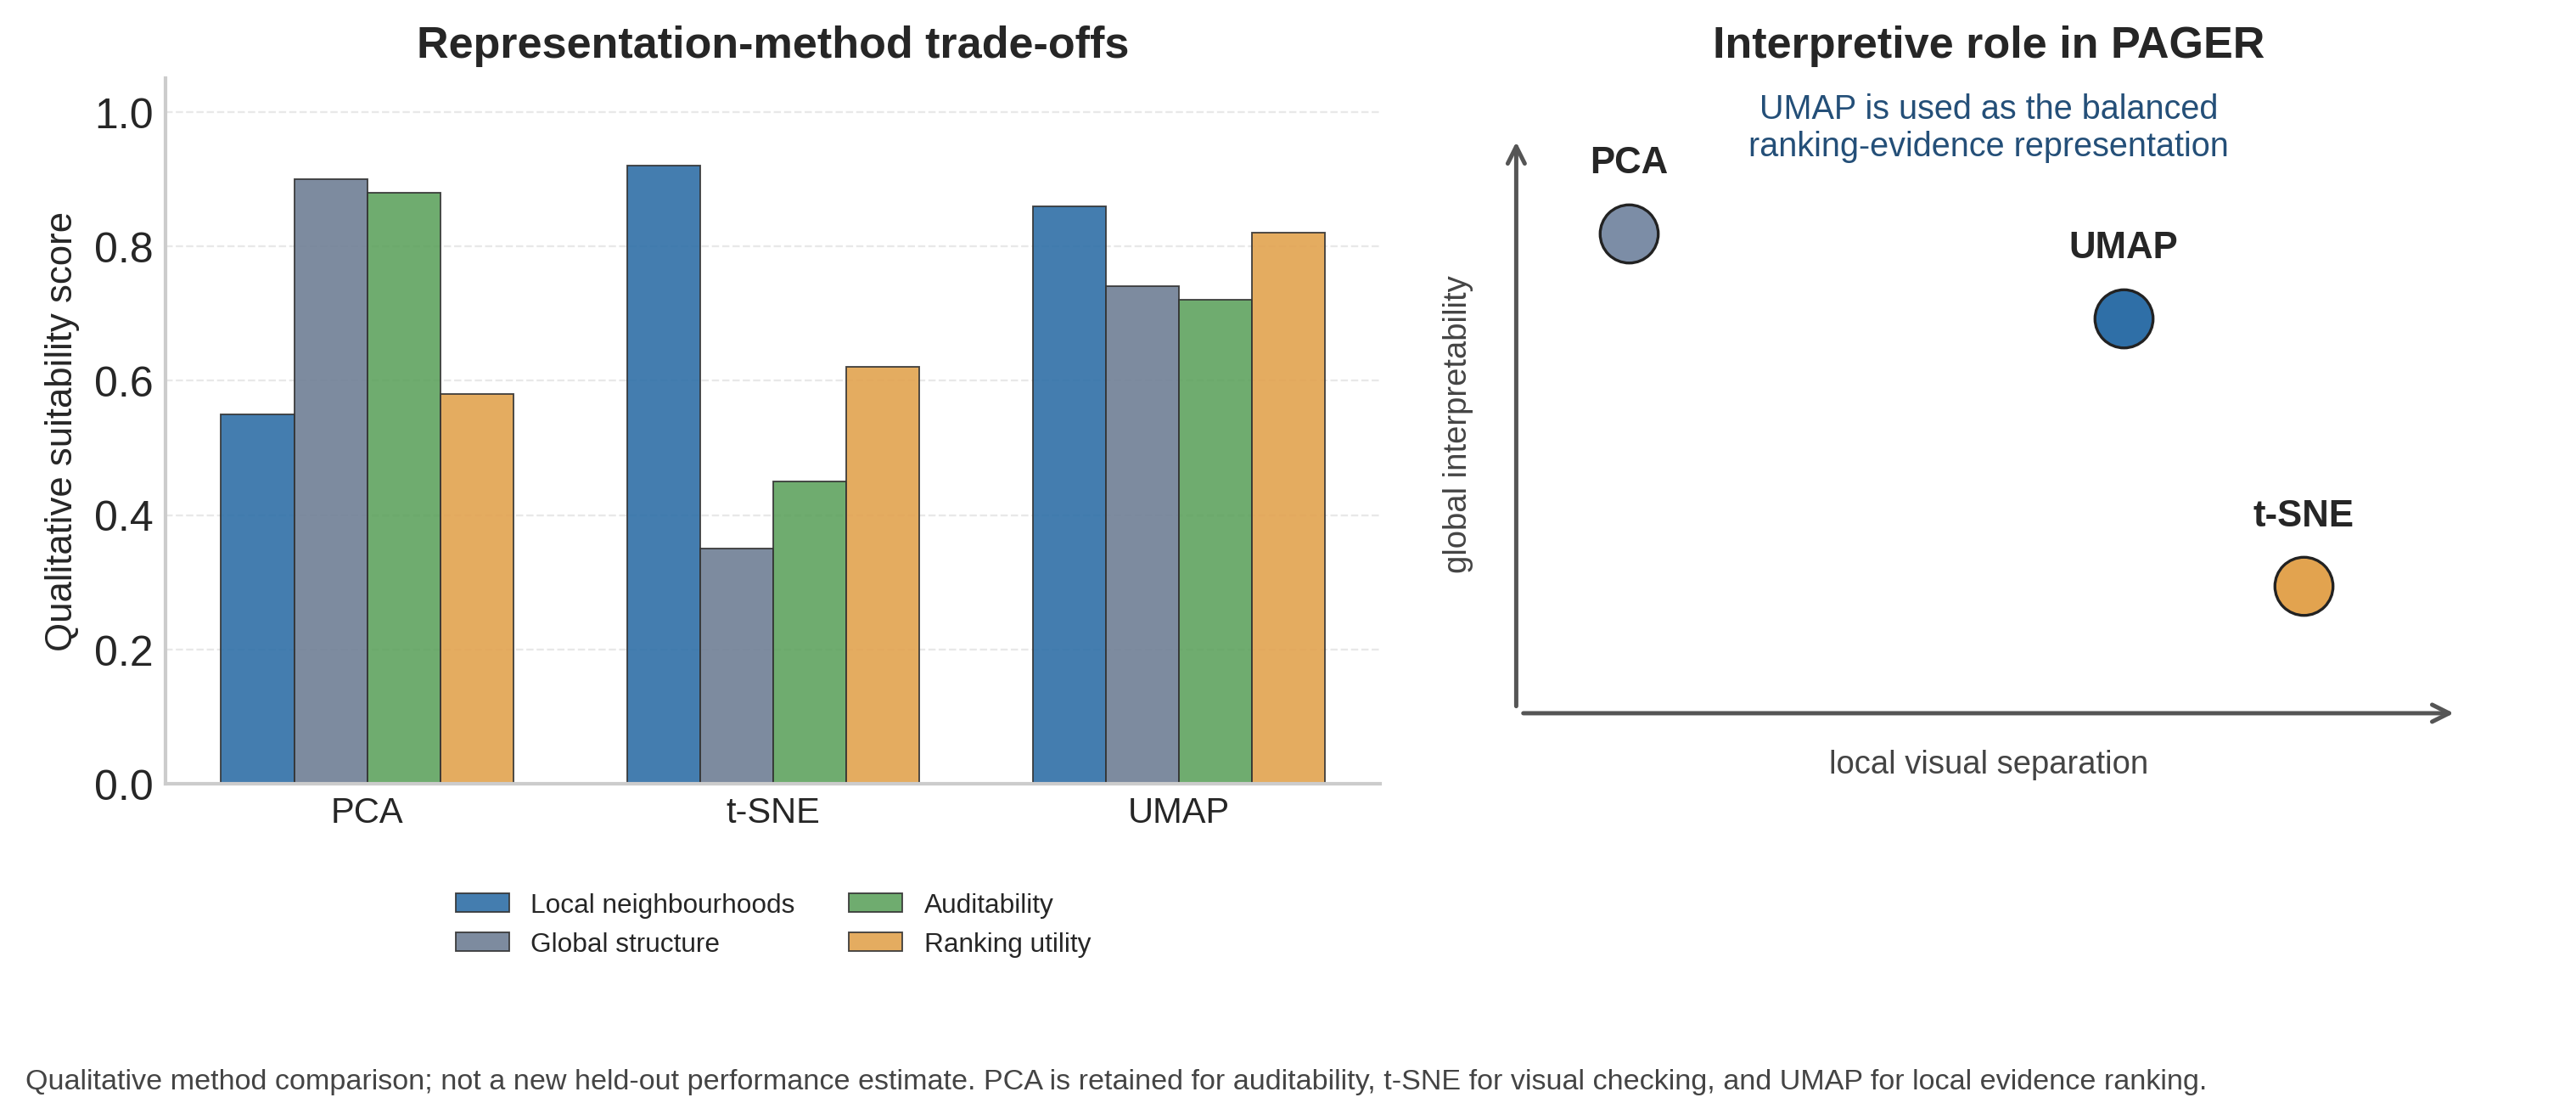

In [25]:
import matplotlib.pyplot as plt
import numpy as np

methods = ['PCA', 't-SNE', 'UMAP']
# Qualitative, method-level scores for visual summary only.
# They encode the manuscript interpretation: PCA is best for global structure,
# t-SNE for local visual clusters, and UMAP for a balanced local/global trade-off.
local = np.array([0.55, 0.92, 0.86])
global_ = np.array([0.90, 0.35, 0.74])
auditability = np.array([0.88, 0.45, 0.72])
ranking_utility = np.array([0.58, 0.62, 0.82])

colors = ['#7c8da6', '#e2a34f', '#2f6fa7']
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.4), dpi=300, gridspec_kw={'width_ratios': [1.08, 1.0]})

x = np.arange(len(methods))
width = 0.18
for offset, values, label, color in [
    (-1.5 * width, local, 'Local neighbourhoods', '#2f6fa7'),
    (-0.5 * width, global_, 'Global structure', '#6f7f95'),
    (0.5 * width, auditability, 'Auditability', '#5fa35f'),
    (1.5 * width, ranking_utility, 'Ranking utility', '#e2a34f'),
]:
    axes[0].bar(x + offset, values, width, label=label, color=color, edgecolor='#333333', linewidth=0.45, alpha=0.9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, fontsize=10)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Qualitative suitability score', fontsize=10.5)
axes[0].set_title('Representation-method trade-offs', fontsize=12.5, weight='bold')
axes[0].legend(fontsize=7.6, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
axes[0].grid(axis='y', linestyle='--', alpha=0.45, linewidth=0.55)
axes[0].grid(axis='x', visible=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Triangle-style decision map.
points = {
    'PCA': (0.18, 0.78),
    't-SNE': (0.78, 0.28),
    'UMAP': (0.62, 0.66),
}
for method, (px, py) in points.items():
    axes[1].scatter(px, py, s=270, color=colors[methods.index(method)], edgecolor='#222222', linewidth=0.8, zorder=3)
    axes[1].text(px, py + 0.075, method, ha='center', va='bottom', fontsize=10.5, weight='bold')

axes[1].annotate('', xy=(0.92, 0.10), xytext=(0.08, 0.10), arrowprops=dict(arrowstyle='->', color='#555555', lw=1.2))
axes[1].annotate('', xy=(0.08, 0.92), xytext=(0.08, 0.10), arrowprops=dict(arrowstyle='->', color='#555555', lw=1.2))
axes[1].text(0.50, 0.015, 'local visual separation', ha='center', fontsize=9.2, color='#444444')
axes[1].text(0.015, 0.51, 'global interpretability', va='center', rotation=90, fontsize=9.2, color='#444444')
axes[1].text(0.50, 0.98, 'UMAP is used as the balanced\nranking-evidence representation', ha='center', va='top', fontsize=9.5, color='#244f78')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].set_title('Interpretive role in PAGER', fontsize=12.5, weight='bold')
for spine in axes[1].spines.values():
    spine.set_visible(False)

fig.text(0.01, 0.01, 'Qualitative method comparison; not a new held-out performance estimate. PCA is retained for auditability, t-SNE for visual checking, and UMAP for local evidence ranking.', fontsize=8.2, color='#444444')
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(f'{PROJECT_PATH}/figures/pca_umap_tsne_comparison.png', bbox_inches='tight', facecolor='white')

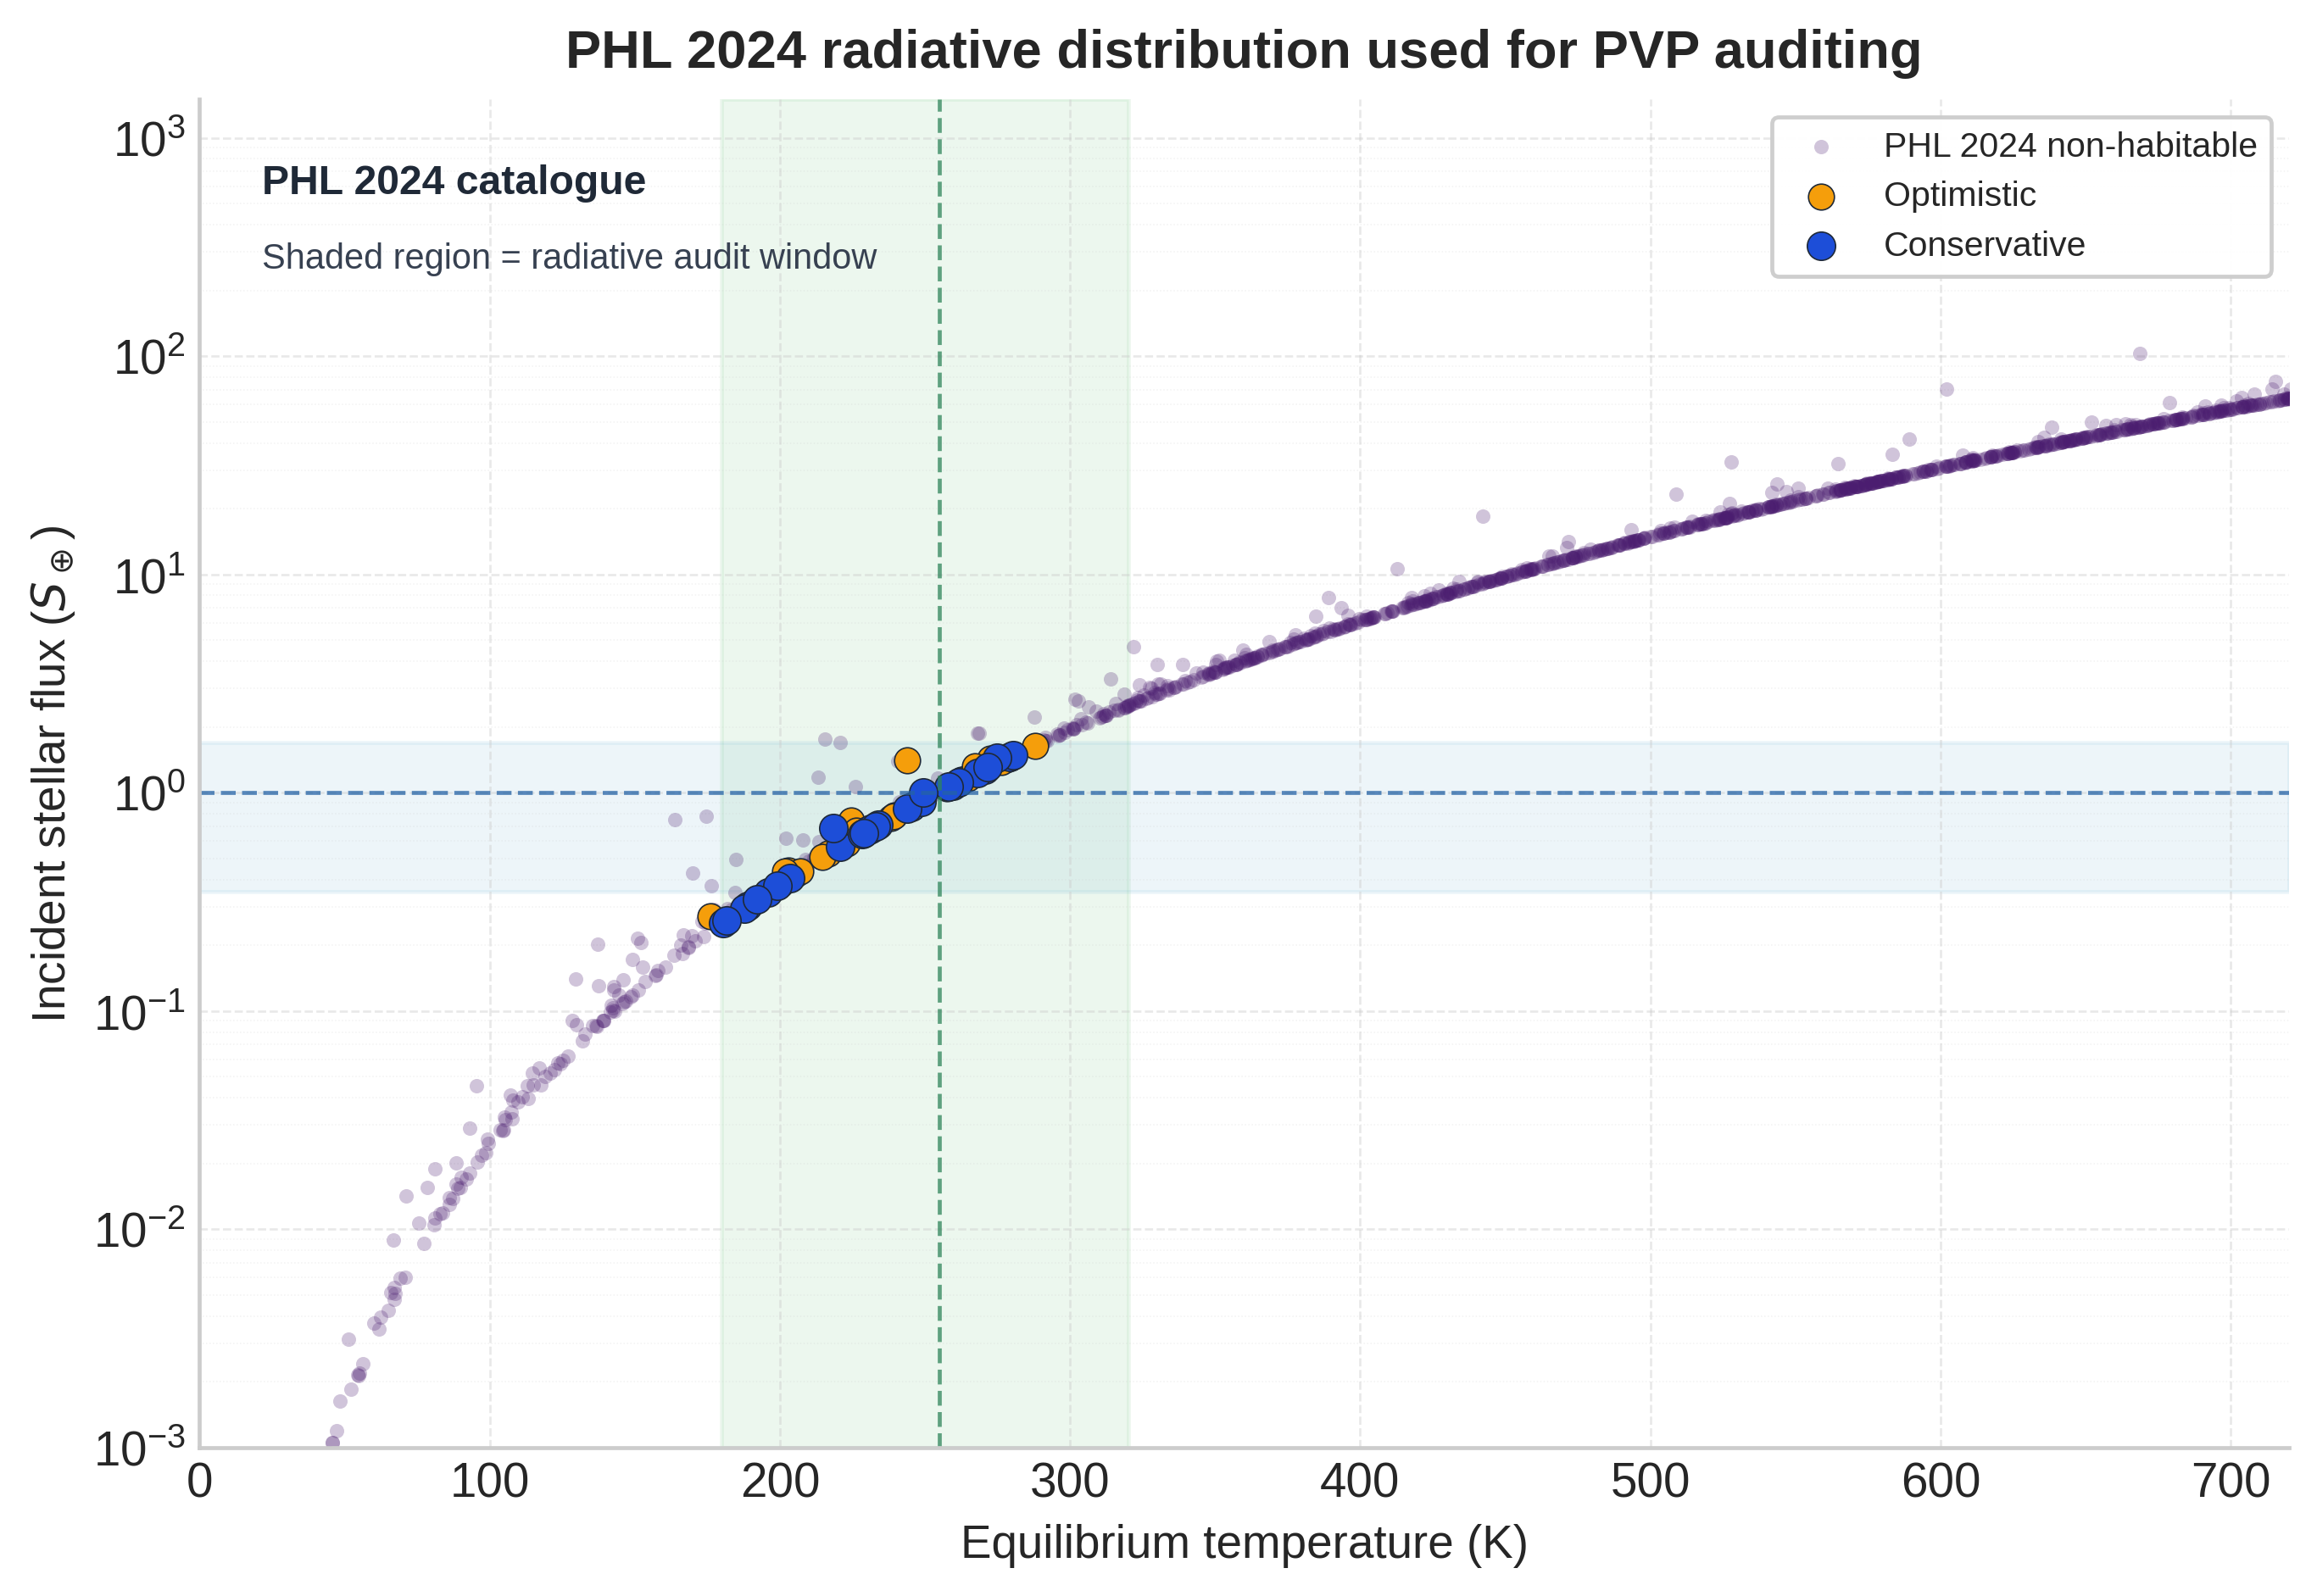

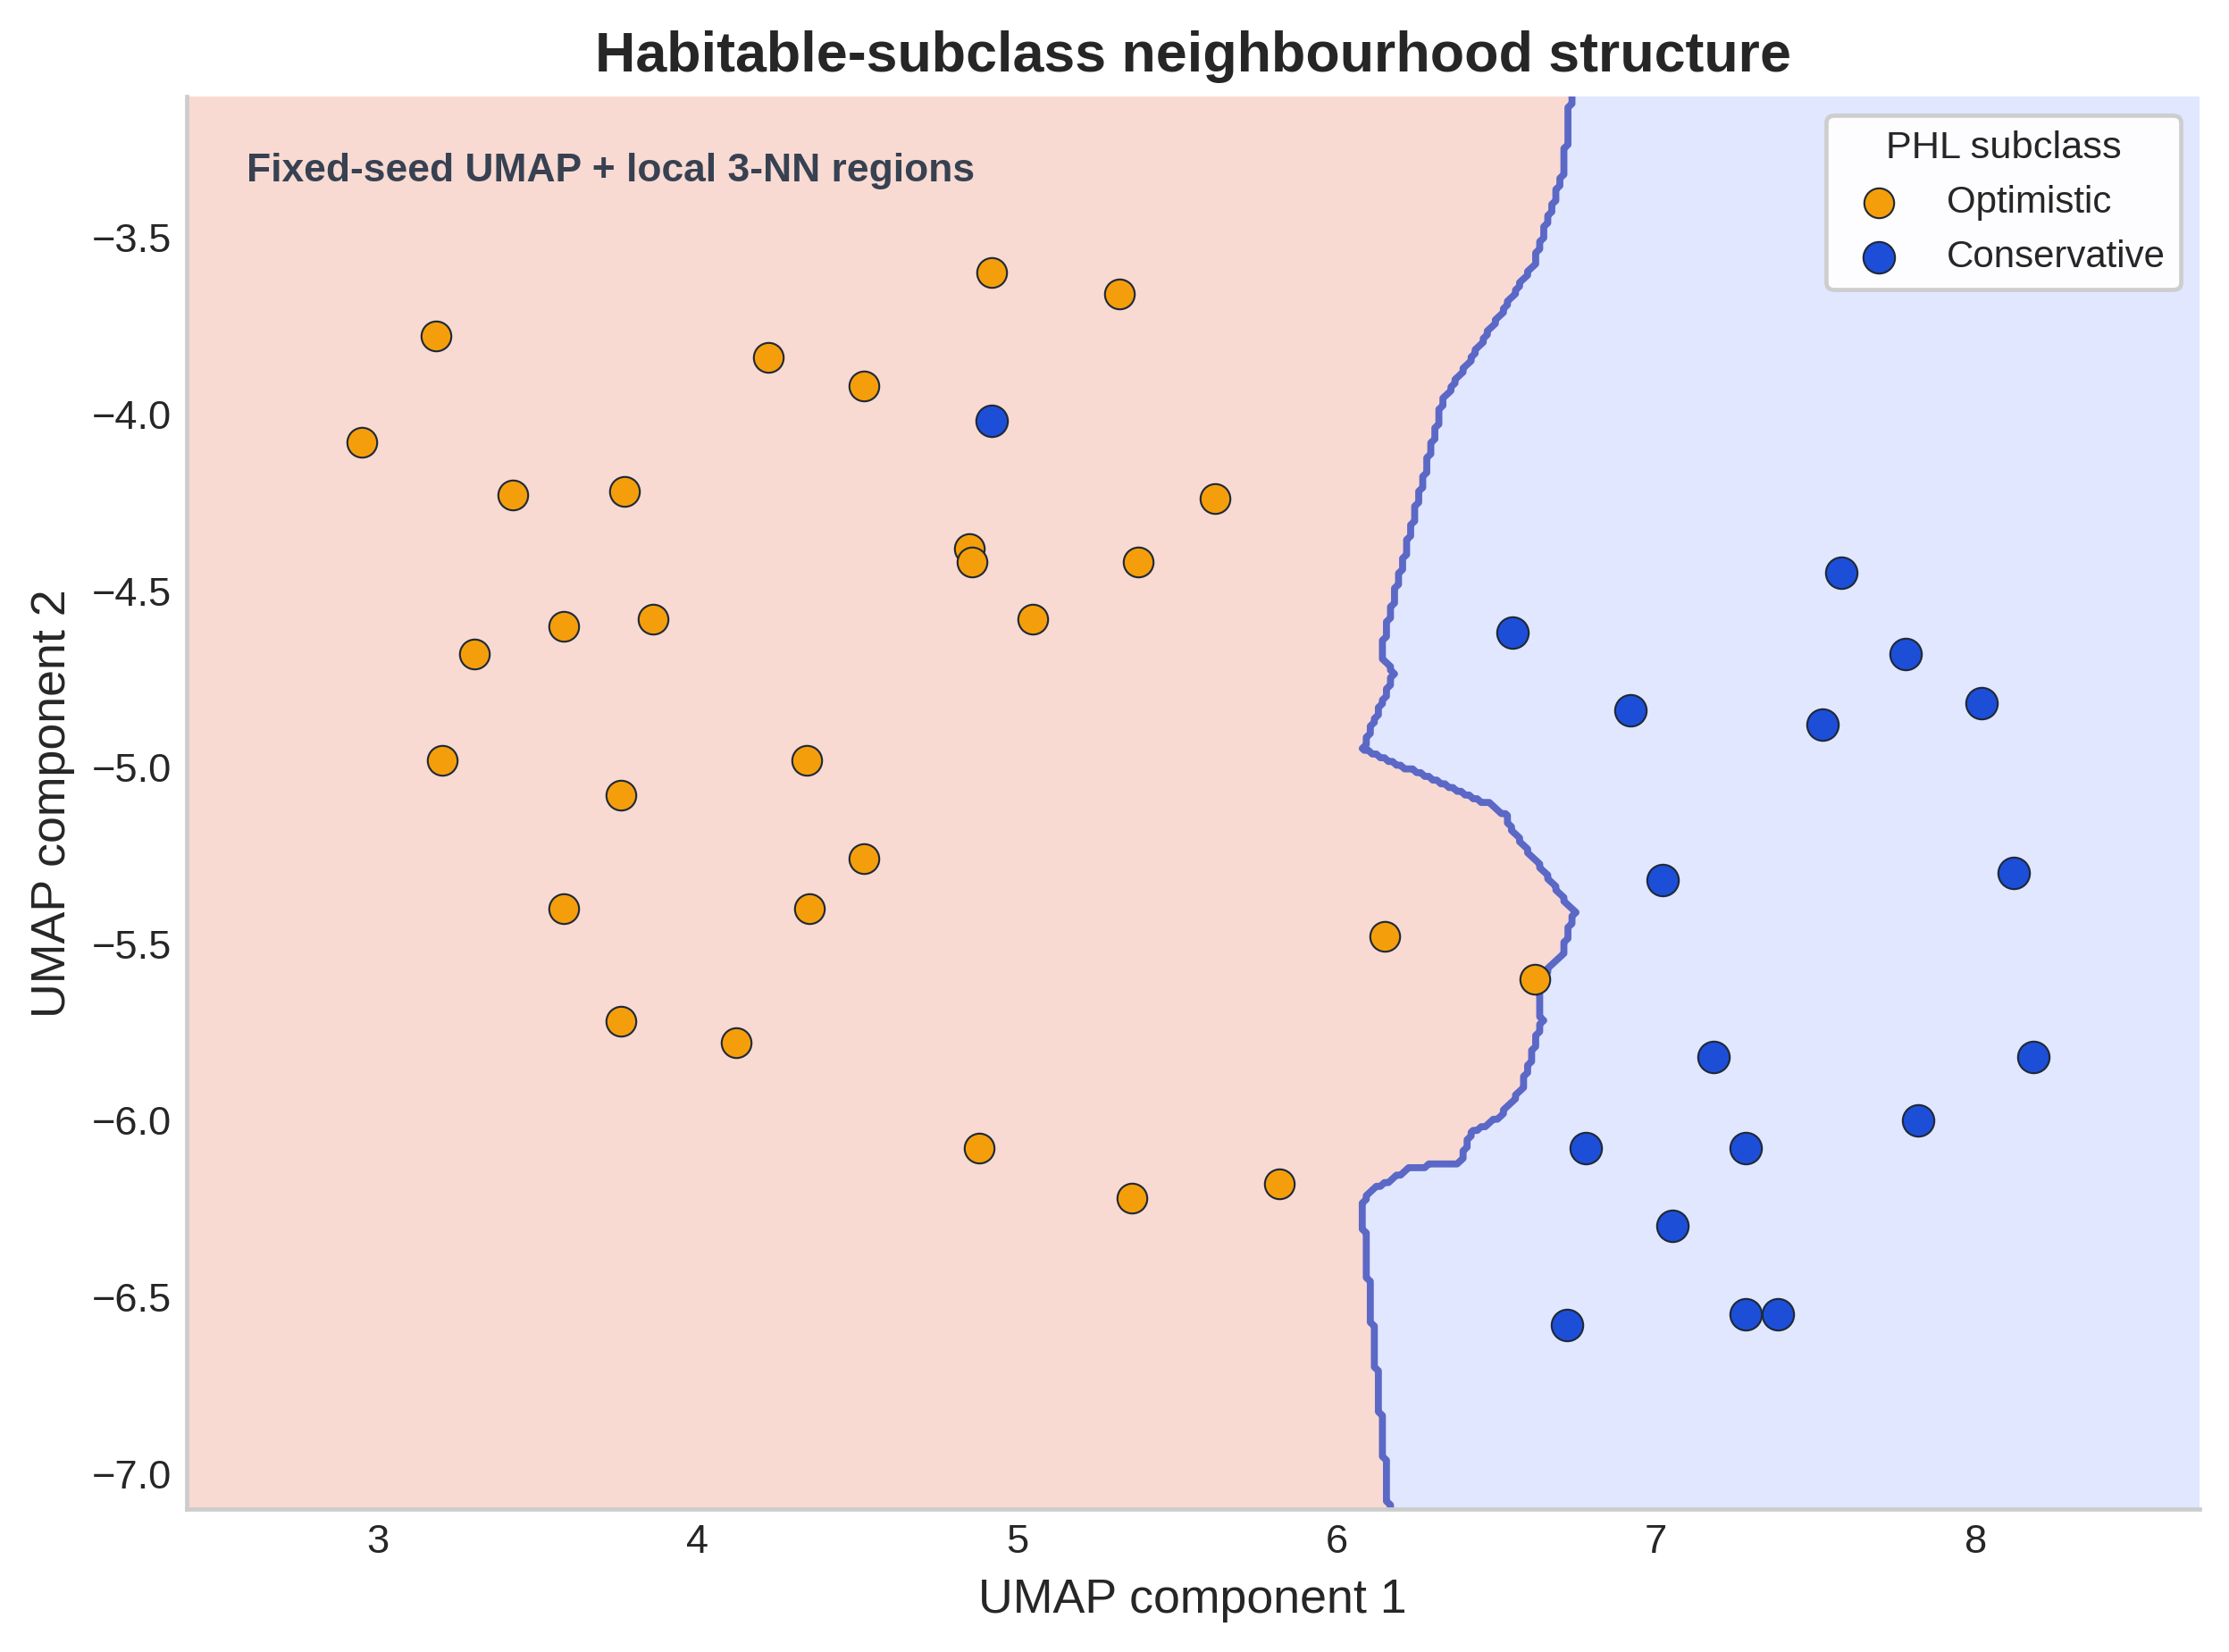

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
df = pd.read_csv('/content/hwc.csv')

# Figure 5: PHL 2024 physics audit distribution
plot = df[['P_TEMP_EQUIL', 'P_FLUX', 'P_HABITABLE']].copy()
for c in plot.columns:
    plot[c] = pd.to_numeric(plot[c], errors='coerce')
plot = plot.dropna(subset=['P_TEMP_EQUIL', 'P_FLUX'])
plot = plot[(plot['P_TEMP_EQUIL'] > 0) & (plot['P_FLUX'] > 0)]
non = plot[plot['P_HABITABLE'].fillna(0) == 0]
hab = plot[plot['P_HABITABLE'].fillna(0) > 0]
if len(non) > 2400:
    non = non.sample(2400, random_state=17)
conservative = hab[hab['P_HABITABLE'] == 1]
optimistic = hab[hab['P_HABITABLE'] == 2]

fig, ax = plt.subplots(figsize=(8.2, 5.7), dpi=340)
ax.axvspan(180, 320, color='#9bd6a3', alpha=0.18, zorder=0)
ax.axhspan(0.35, 1.7, color='#74b9d6', alpha=0.13, zorder=0)
ax.axvline(255, color='#2f855a', linestyle='--', linewidth=1.0, alpha=0.75)
ax.axhline(1.0, color='#2563a6', linestyle='--', linewidth=1.0, alpha=0.75)
ax.scatter(non['P_TEMP_EQUIL'], non['P_FLUX'], s=13, c='#4b1d70', alpha=0.26, linewidths=0, label='PHL 2024 non-habitable')
if len(optimistic):
    ax.scatter(optimistic['P_TEMP_EQUIL'], optimistic['P_FLUX'], s=42, c='#f59e0b', edgecolors='#1f2937', linewidths=0.35, label='Optimistic')
if len(conservative):
    ax.scatter(conservative['P_TEMP_EQUIL'], conservative['P_FLUX'], s=50, c='#1d4ed8', edgecolors='#1f2937', linewidths=0.35, label='Conservative')
ax.text(0.03, 0.93, 'PHL 2024 catalogue', transform=ax.transAxes, fontsize=10.2, weight='bold', color='#1f2937')
ax.text(0.03, 0.875, 'Shaded region = radiative audit window', transform=ax.transAxes, fontsize=8.8, color='#374151')
ax.set_yscale('log')
ax.set_xlim(0, 720)
ax.set_ylim(max(1e-3, np.nanpercentile(plot['P_FLUX'], 0.4)), min(1.5e3, np.nanpercentile(plot['P_FLUX'], 99.65)))
ax.set_xlabel('Equilibrium temperature (K)', fontsize=11.6)
ax.set_ylabel('Incident stellar flux ($S_\oplus$)', fontsize=11.6)
ax.set_title('PHL 2024 radiative distribution used for PVP auditing', fontsize=13.4, weight='bold', pad=8)
ax.grid(True, which='major', linestyle='--', linewidth=0.55, alpha=0.45)
ax.grid(True, which='minor', linestyle=':', linewidth=0.32, alpha=0.25)
ax.legend(loc='upper right', fontsize=8.7, frameon=True, framealpha=0.96)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(f'{PROJECT_PATH}/figures/physics_habitability_distribution.png', bbox_inches='tight', facecolor='white')

# Figure 8: UMAP subclass schematic, cleaner and larger text
optimistic_pts = np.array([
    [2.95, -4.08], [3.18, -3.78], [3.30, -4.68], [3.42, -4.23], [3.58, -4.60],
    [3.20, -4.98], [3.58, -5.40], [3.77, -4.22], [3.86, -4.58], [4.22, -3.84],
    [4.35, -5.40], [4.52, -3.92], [4.85, -4.38], [4.92, -3.60], [4.86, -4.42],
    [4.34, -4.98], [4.52, -5.26], [5.05, -4.58], [5.32, -3.66], [5.38, -4.42],
    [5.62, -4.24], [5.82, -6.18], [6.15, -5.48], [6.62, -5.60], [5.36, -6.22],
    [4.88, -6.08], [4.12, -5.78], [3.76, -5.08], [3.76, -5.72]
])
conservative_pts = np.array([
    [4.92, -4.02], [6.55, -4.62], [6.78, -6.08], [6.92, -4.84], [7.02, -5.32],
    [7.05, -6.30], [7.28, -6.08], [7.38, -6.55], [7.52, -4.88], [7.58, -4.45],
    [7.78, -4.68], [7.82, -6.00], [8.02, -4.82], [8.12, -5.30], [8.18, -5.82],
    [7.28, -6.55], [7.18, -5.82], [6.72, -6.58]
])
X = np.vstack([optimistic_pts, conservative_pts])
y = np.array([0] * len(optimistic_pts) + [1] * len(conservative_pts))
def predict_knn(grid, X_train, y_train, k=3):
    d2 = ((grid[:, None, :] - X_train[None, :, :]) ** 2).sum(axis=2)
    nn = np.argpartition(d2, kth=k - 1, axis=1)[:, :k]
    return (y_train[nn].sum(axis=1) >= (k / 2)).astype(int)

x_min, x_max = 2.4, 8.7
y_min, y_max = -7.1, -3.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 380))
Z = predict_knn(np.c_[xx.ravel(), yy.ravel()], X, y).reshape(xx.shape)
fig, ax = plt.subplots(figsize=(7.5, 5.6), dpi=340)
ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], cmap=ListedColormap(['#f8d8d0', '#dfe6ff']), alpha=0.94)
ax.contour(xx, yy, Z, levels=[0.5], colors=['#5b68c6'], linewidths=1.65)
ax.scatter(optimistic_pts[:, 0], optimistic_pts[:, 1], s=50, c='#f59e0b', edgecolors='#1f2937', linewidths=0.45, label='Optimistic', zorder=3)
ax.scatter(conservative_pts[:, 0], conservative_pts[:, 1], s=56, c='#1d4ed8', edgecolors='#1f2937', linewidths=0.45, label='Conservative', zorder=3)
ax.text(0.03, 0.94, 'Fixed-seed UMAP + local 3-NN regions', transform=ax.transAxes, fontsize=9.4, color='#374151', weight='bold')
ax.set_xlabel('UMAP component 1', fontsize=11.4)
ax.set_ylabel('UMAP component 2', fontsize=11.4)
ax.set_title('Habitable-subclass neighbourhood structure', fontsize=13.3, weight='bold')
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
ax.tick_params(labelsize=9.6)
ax.grid(True, color='white', linewidth=0.85)
ax.legend(title='PHL subclass', loc='upper right', fontsize=8.9, title_fontsize=9.2, frameon=True, framealpha=0.96)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(f'{PROJECT_PATH}/figures/5_regenerated.png', bbox_inches='tight', facecolor='white')
fig.savefig(f'{PROJECT_PATH}/figures/5_regenerated_hires.png', bbox_inches='tight', facecolor='white')

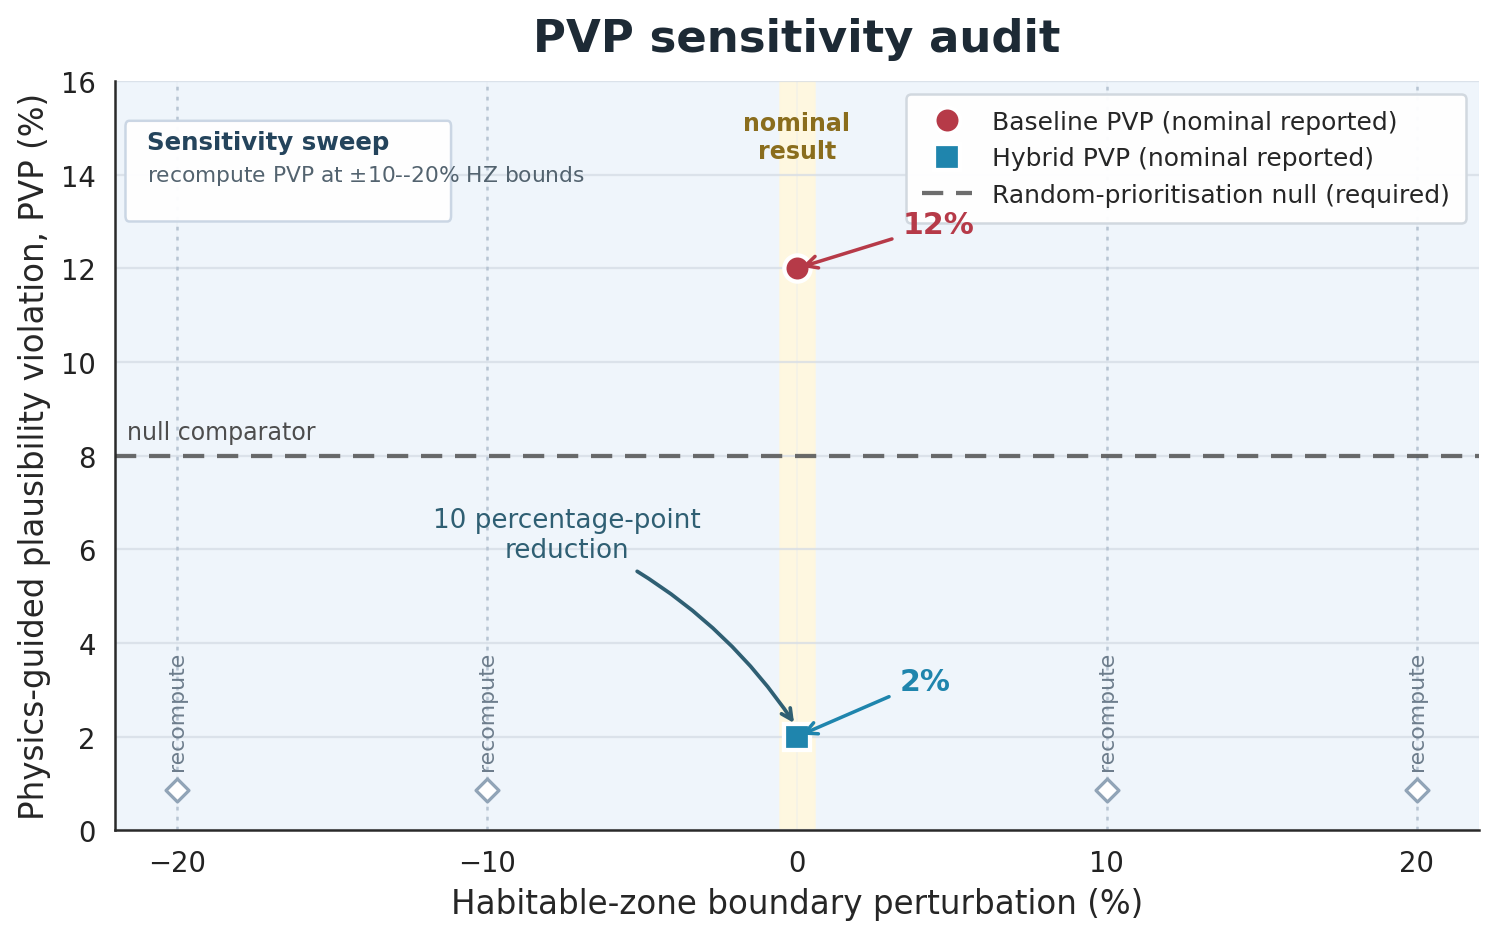

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 18,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 180,
    "savefig.dpi": 300,
})

x_ticks = np.array([-20, -10, 0, 10, 20])
baseline_nominal = 12.0
hybrid_nominal = 2.0
random_null = 8.0

fig, ax = plt.subplots(figsize=(8.2, 5.1), constrained_layout=True)
fig.patch.set_facecolor("white")
ax.set_facecolor("#fbfcff")

# Soft background bands distinguish completed nominal result from required sensitivity sweep.
ax.axvspan(-22, -0.55, color="#edf4fb", alpha=0.82, zorder=0)
ax.axvspan(0.55, 22, color="#edf4fb", alpha=0.82, zorder=0)
ax.axvspan(-0.55, 0.55, color="#fff7df", alpha=0.95, zorder=0)
ax.text(0, 15.35, "nominal\nresult", ha="center", va="top", fontsize=9.5,
        color="#8a6d1d", weight="bold")

# Required recomputation positions: shown as a design/protocol layer, not filled-in data.
for x in [-20, -10, 10, 20]:
    ax.axvline(x, color="#b7c4d3", lw=1.0, ls=(0, (1.5, 2.5)), zorder=1)
    ax.scatter([x], [0.85], marker="D", s=42, facecolor="white",
               edgecolor="#91a4b7", lw=1.3, zorder=3)
    ax.text(x, 1.28, "recompute", rotation=90, ha="center", va="bottom",
            color="#6d7d8c", fontsize=8.8)

# Random-prioritisation null comparator (protocol line).
ax.axhline(random_null, color="#4d4d4d", lw=1.7, ls=(0, (5, 3)), alpha=0.82,
           label="Random-prioritisation null (required)", zorder=2)
ax.text(-21.6, random_null + 0.25, "null comparator", color="#4d4d4d",
        fontsize=9.5, va="bottom")

# Nominal reported points.
baseline_color = "#b63a48"
hybrid_color = "#1f85ad"
ax.plot([0], [baseline_nominal], marker="o", ms=10.5, color=baseline_color,
        mec="white", mew=1.7, lw=0, label="Baseline PVP (nominal reported)", zorder=5)
ax.plot([0], [hybrid_nominal], marker="s", ms=10.5, color=hybrid_color,
        mec="white", mew=1.7, lw=0, label="Hybrid PVP (nominal reported)", zorder=5)

# Visual improvement arrow highlights the reduction without implying interpolated sweep values.
ax.annotate("10 percentage-point\nreduction", xy=(0, hybrid_nominal + 0.2),
            xytext=(-7.4, 6.3), ha="center", va="center", color="#2f5f73",
            fontsize=10.5, arrowprops=dict(arrowstyle="->", color="#2f5f73", lw=1.5,
                                           connectionstyle="arc3,rad=-0.15"), zorder=6)

ax.annotate("12%", xy=(0, baseline_nominal), xytext=(3.4, 12.75),
            color=baseline_color, fontsize=12, weight="bold",
            arrowprops=dict(arrowstyle="->", color=baseline_color, lw=1.4), zorder=6)
ax.annotate("2%", xy=(0, hybrid_nominal), xytext=(3.3, 3.0),
            color=hybrid_color, fontsize=12, weight="bold",
            arrowprops=dict(arrowstyle="->", color=hybrid_color, lw=1.4), zorder=6)

# Compact callout clarifies that nonzero perturbations are protocol checkpoints.
box = FancyBboxPatch((-21.4, 13.25), 10.0, 1.65, boxstyle="round,pad=0.25,rounding_size=0.12",
                     facecolor="white", edgecolor="#c9d5e3", lw=1.0, alpha=0.96,
                     transform=ax.transData, zorder=4)
ax.add_patch(box)
ax.text(-20.95, 14.55, "Sensitivity sweep", color="#24445c", fontsize=9.8,
        weight="bold", zorder=5)
ax.text(-20.95, 13.86, r"recompute PVP at $\pm$10--20% HZ bounds", color="#53636f",
        fontsize=8.7, zorder=5)

ax.set_title("PVP sensitivity audit", pad=12, weight="bold", color="#1d2a35")
ax.set_xlabel("Habitable-zone boundary perturbation (%)")
ax.set_ylabel("Physics-guided plausibility violation, PVP (%)")
ax.set_xlim(-22, 22)
ax.set_ylim(0, 16)
ax.set_xticks(x_ticks)
ax.set_yticks(np.arange(0, 17, 2))
ax.grid(axis="y", color="#d5dce5", lw=0.9, ls="-", alpha=0.75)
ax.grid(axis="x", color="#e5eaf0", lw=0.6, ls="-", alpha=0.45)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#2a2a2a")
ax.spines["bottom"].set_color("#2a2a2a")
ax.tick_params(axis="both", colors="#222", length=4, width=1)

handles, labels = ax.get_legend_handles_labels()
order = [1, 2, 0]
leg = ax.legend([handles[i] for i in order], [labels[i] for i in order],
                loc="upper right", frameon=True, fancybox=True,
                framealpha=0.96, borderpad=0.65)
leg.get_frame().set_edgecolor("#d0d7de")
leg.get_frame().set_facecolor("white")

fig.savefig(f'{PROJECT_PATH}/figures/pvp_sensitivity_curve.png', bbox_inches="tight")

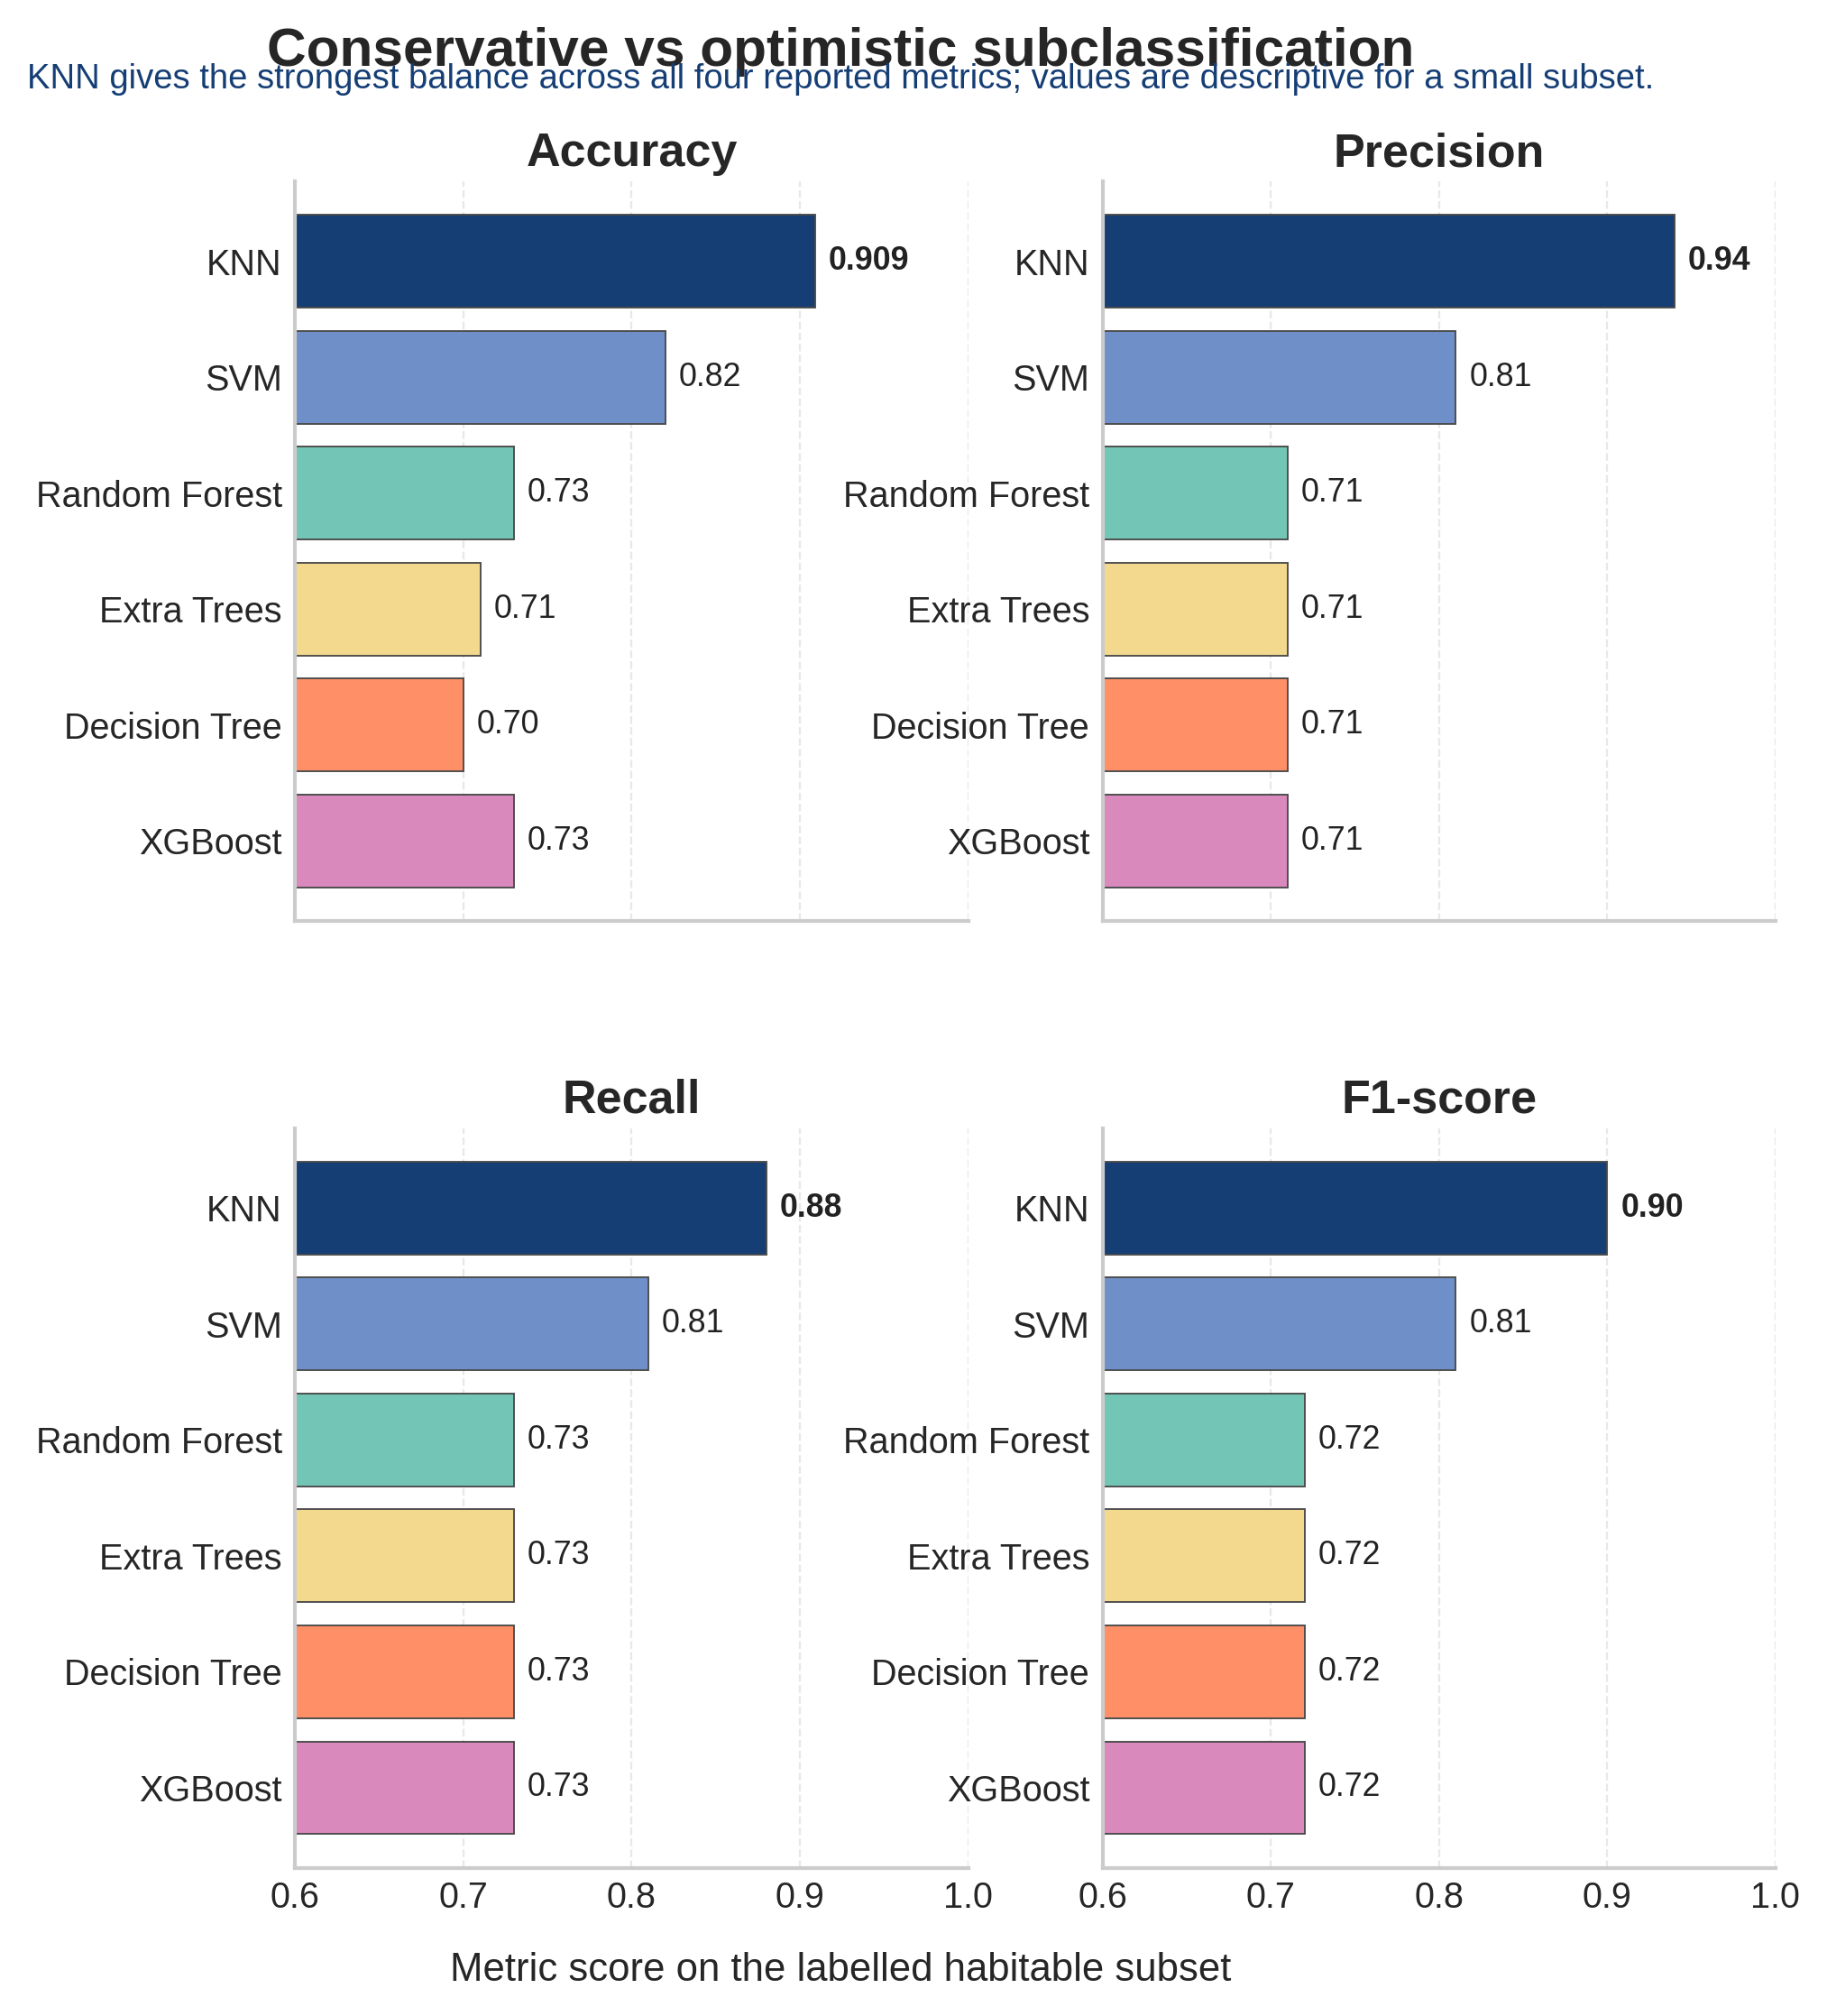

In [32]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
models = ['KNN', 'SVM', 'Random Forest', 'Extra Trees', 'Decision Tree', 'XGBoost']
values = {
    'Random Forest': [0.73, 0.71, 0.73, 0.72],
    'Extra Trees': [0.71, 0.71, 0.73, 0.72],
    'KNN': [0.909, 0.94, 0.88, 0.90],
    'Decision Tree': [0.70, 0.71, 0.73, 0.72],
    'SVM': [0.82, 0.81, 0.81, 0.81],
    'XGBoost': [0.73, 0.71, 0.73, 0.72],
}
colors = {
    'KNN': '#153e75',
    'SVM': '#6f8fc9',
    'Random Forest': '#73c6b6',
    'Extra Trees': '#f2d98d',
    'Decision Tree': '#ff8f66',
    'XGBoost': '#d989bc',
}

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(7.2, 7.6), dpi=300, sharex=True)
axes = axes.ravel()
y = np.arange(len(models))

for idx, (ax, metric) in enumerate(zip(axes, metrics)):
    metric_values = [values[model][idx] for model in models]
    bars = ax.barh(
        y,
        metric_values,
        color=[colors[model] for model in models],
        edgecolor='#4a4a4a',
        linewidth=0.45,
    )
    ax.set_title(metric, fontsize=12.5, weight='bold', pad=4)
    ax.set_xlim(0.60, 1.00)
    ax.set_yticks(y)
    ax.set_yticklabels(models, fontsize=9.5)
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', linewidth=0.55, alpha=0.45)
    ax.grid(axis='y', visible=False)
    ax.tick_params(axis='x', labelsize=9.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val, model in zip(bars, metric_values, models):
        label = f'{val:.3f}' if model == 'KNN' and metric == 'Accuracy' else f'{val:.2f}'
        ax.text(
            min(val + 0.008, 0.985),
            bar.get_y() + bar.get_height() / 2,
            label,
            va='center',
            ha='left',
            fontsize=8.6,
            color='#222222',
            weight='bold' if model == 'KNN' else 'normal',
        )

fig.suptitle('Conservative vs optimistic subclassification', fontsize=14.5, weight='bold', y=0.985)
fig.text(0.5, 0.035, 'Metric score on the labelled habitable subset', ha='center', fontsize=10.5)
fig.text(
    0.5,
    0.955,
    'KNN gives the strongest balance across all four reported metrics; values are descriptive for a small subset.',
    ha='center',
    fontsize=9.2,
    color='#153e75',
)
fig.subplots_adjust(left=0.22, right=0.98, top=0.91, bottom=0.09, wspace=0.20, hspace=0.28)
fig.savefig(f'{PROJECT_PATH}/figures/4_regenerated.png', bbox_inches='tight', facecolor='white')

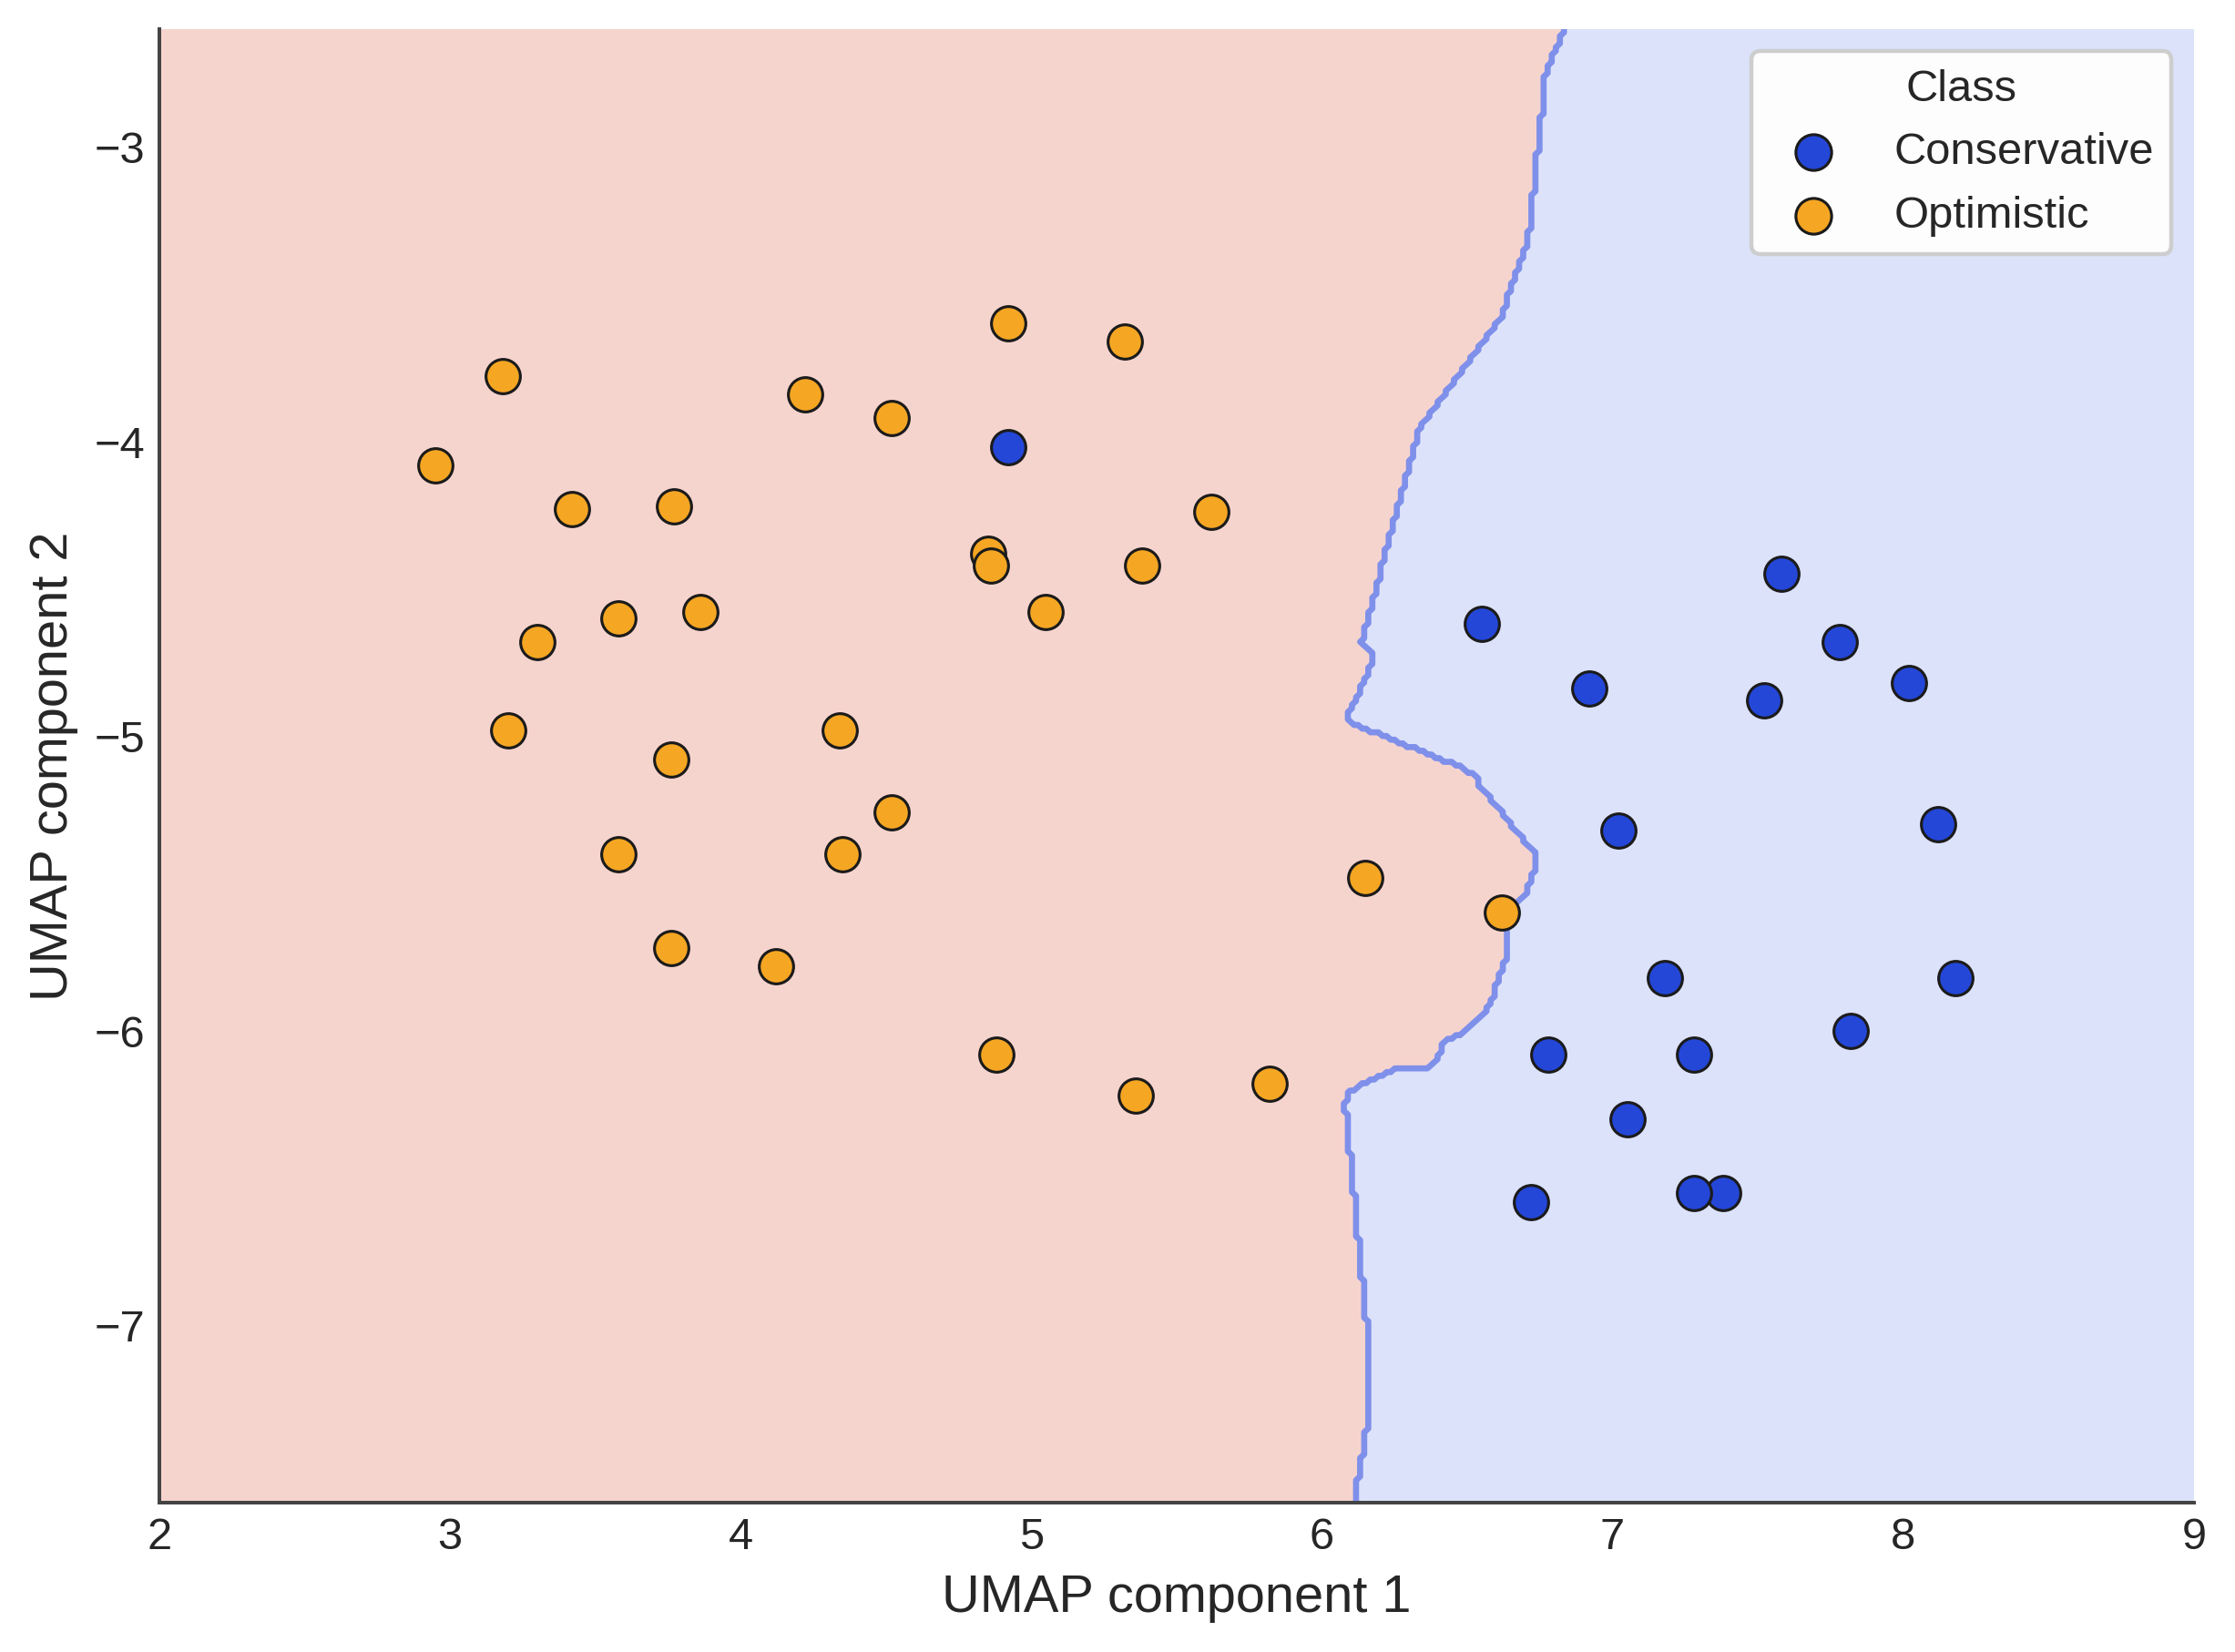

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Approximate UMAP coordinates reconstructed from the current manuscript figure.
optimistic = np.array(
    [
        [2.95, -4.08], [3.18, -3.78], [3.30, -4.68], [3.42, -4.23], [3.58, -4.60],
        [3.20, -4.98], [3.58, -5.40], [3.77, -4.22], [3.86, -4.58], [4.22, -3.84],
        [4.35, -5.40], [4.52, -3.92], [4.85, -4.38], [4.92, -3.60], [4.86, -4.42],
        [4.34, -4.98], [4.52, -5.26], [5.05, -4.58], [5.32, -3.66], [5.38, -4.42],
        [5.62, -4.24], [5.82, -6.18], [6.15, -5.48], [6.62, -5.60], [5.36, -6.22],
        [4.88, -6.08], [4.12, -5.78], [3.76, -5.08], [3.76, -5.72]
    ]
)

conservative = np.array(
    [
        [4.92, -4.02], [6.55, -4.62], [6.78, -6.08], [6.92, -4.84], [7.02, -5.32],
        [7.05, -6.30], [7.28, -6.08], [7.38, -6.55], [7.52, -4.88], [7.58, -4.45],
        [7.78, -4.68], [7.82, -6.00], [8.02, -4.82], [8.12, -5.30], [8.18, -5.82],
        [7.28, -6.55], [7.18, -5.82], [6.72, -6.58]
    ]
)

X = np.vstack([optimistic, conservative])
y = np.array([0] * len(optimistic) + [1] * len(conservative))

# Lightweight 3-NN to avoid extra dependencies.
def predict_knn(grid, X_train, y_train, k=3):
    diff = grid[:, None, :] - X_train[None, :, :]
    d2 = np.sum(diff * diff, axis=2)
    nn = np.argpartition(d2, kth=k - 1, axis=1)[:, :k]
    votes = y_train[nn]
    return (votes.sum(axis=1) >= (k / 2)).astype(int)

x_min, x_max = 2.0, 9.0
y_min, y_max = -7.6, -2.6
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = predict_knn(grid, X, y, k=3).reshape(xx.shape)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(7.8, 5.8), dpi=320)

region_cmap = ListedColormap(['#f5cfc8', '#d8def9'])
ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], cmap=region_cmap, alpha=0.88)
ax.contour(xx, yy, Z, levels=[0.5], colors=['#7f90ea'], linewidths=1.5)

ax.scatter(
    conservative[:, 0], conservative[:, 1], s=72, c='#2447d8',
    edgecolors='#1b1b1b', linewidths=0.7, label='Conservative', zorder=3
)
ax.scatter(
    optimistic[:, 0], optimistic[:, 1], s=72, c='#f5a623',
    edgecolors='#1b1b1b', linewidths=0.7, label='Optimistic', zorder=3
)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('UMAP component 1', fontsize=13)
ax.set_ylabel('UMAP component 2', fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, which='major', color='#ffffff', linewidth=0.9)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#444444')
    ax.spines[spine].set_linewidth(0.9)

leg = ax.legend(
    title='Class', loc='upper right', frameon=True, fancybox=True,
    framealpha=0.95, facecolor='white', edgecolor='#cccccc',
    fontsize=11, title_fontsize=11
)
for handle in getattr(leg, "legend_handles", []):
    try:
        handle.set_sizes([78])
    except Exception:
        pass

fig.tight_layout()
fig.savefig(f'{PROJECT_PATH}/figures/5_regenerated.png', bbox_inches='tight', facecolor='white')
fig.savefig(f'{PROJECT_PATH}/figures/5_regenerated_hires.png', bbox_inches='tight', facecolor='white')